# 06. High Level Analysis & Comparison

This notebook compares the optimal configurations identified in previous analyses:
1. **PV Only** (from Oversizing Analysis)
2. **Wind Only** (from Oversizing Analysis)
3. **Hybrid PV + Wind** (from Oversizing Analysis)
4. **PV + BESS** (from PV+BESS Analysis)
5. **Wind + BESS** (from Wind+BESS Analysis)
6. **Hybrid + BESS** (from PV+Wind+BESS Analysis)
7. **Innovation (PV+BESS)** (from PV+Wind+BESS Analysis)
8. **Innovation (Wind+BESS)** (from Wind+BESS Analysis)

We compare them across key metrics:
- **NPV (Net Present Value)**
- **IRR (Internal Rate of Return)**
- **POI Utilisation**
- **Curtailment**

In [87]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # pyright: ignore[reportMissingModuleSource]
from pathlib import Path

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Project root setup
project_root = Path("..").resolve()
if not (project_root / "data_processed").exists():
    # Fallback if running from notebooks dir
    project_root = Path(".").resolve().parent

sys.path.insert(0, str(project_root / "src"))

from config import (
    CAPEX_PV_EUR_PER_KW,
    OPEX_PV_EUR_PER_KW_PER_YEAR,
    CAPEX_WIND_EUR_PER_KW,
    OPEX_WIND_EUR_PER_KW_PER_YEAR,
)

from economics import irr


print(f"Project Root: {project_root}")


Project Root: /Users/fynnfroehlich/Master Thesis


In [88]:
def calculate_irr_consistent(row):
    """
    Calculate IRR using the same cash flow assumptions as NPV.
    
    IMPORTANT: Handles different lifetimes for different technologies:
    - PV-only: 30 years with 0.25%/year degradation
    - Wind-only: 25 years, no degradation
    - Hybrid: PV for 30y, Wind for 25y (approximated with blended approach)
    - BESS: Replaced at year 15 (30% of initial CAPEX)
    
    This ensures IRR > WACC iff NPV > 0 (mathematical consistency).
    """
    from config import (
        PROJECT_LIFETIME_YEARS, DEGRADATION_PV_PER_YEAR, 
        LIFETIME_BESS_YEARS, BESS_REPLACEMENT_SHARE, CAPEX_BESS_EUR_PER_KWH,
        LIFETIME_WIND_YEARS, LIFETIME_PV_YEARS
    )
    
    capex = row["capex_total_eur"]
    annual_revenue = row.get("annual_revenue_eur", np.nan)
    annual_opex = row.get("annual_opex_total_eur", np.nan)
    
    if pd.isna(annual_revenue) or pd.isna(annual_opex):
        return np.nan
    
    # Get wind share for degradation and lifetime calculation
    s_wind = row.get("s_wind", 0.0)
    if pd.isna(s_wind):
        s_wind = 0.0
    
    # Determine effective project lifetime based on technology mix
    # Wind-only: 25 years, PV-only: 30 years, Hybrid: use PV lifetime (30y)
    if s_wind >= 0.999:  # Wind-only
        n_years = LIFETIME_WIND_YEARS
        degradation = 0.0
    elif s_wind <= 0.001:  # PV-only (with or without BESS)
        n_years = LIFETIME_PV_YEARS
        degradation = DEGRADATION_PV_PER_YEAR
    else:  # Hybrid - use project lifetime, wind portion handled separately
        n_years = PROJECT_LIFETIME_YEARS
        degradation = DEGRADATION_PV_PER_YEAR * (1 - s_wind)  # Blended
    
    # BESS parameters
    bess_energy_mwh = row.get("bess_energy_mwh", 0.0)
    if pd.isna(bess_energy_mwh):
        bess_energy_mwh = 0.0
    has_bess = bess_energy_mwh > 0
    
    # BESS replacement cost at year 15
    bess_replacement_cost = 0.0
    if has_bess:
        bess_capex = bess_energy_mwh * 1000 * CAPEX_BESS_EUR_PER_KWH
        bess_replacement_cost = bess_capex * BESS_REPLACEMENT_SHARE
    
    # Build cash flows
    cash_flows = np.zeros(n_years + 1)
    cash_flows[0] = -capex
    
    for y in range(1, n_years + 1):
        # Revenue degrades based on technology mix
        revenue_y = annual_revenue * (1 - degradation) ** (y - 1)
        cash_flows[y] = revenue_y - annual_opex
        
        # BESS replacement at year 15 (only if within project lifetime)
        if has_bess and y == LIFETIME_BESS_YEARS and y <= n_years:
            cash_flows[y] -= bess_replacement_cost
    
    try:
        return irr(cash_flows)
    except ValueError:
        return np.nan


def _load_csv(path: Path) -> pd.DataFrame:
    if path.exists():
        return pd.read_csv(path)
    print(f"Warning: {path} not found")
    return pd.DataFrame()


def _compute_curtailment_rate(export_mwh, curtailment_mwh):
    total = export_mwh + curtailment_mwh
    return np.where(total > 0, curtailment_mwh / total, 0.0)


def _normalize_pv_oversizing(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    df = df.copy()
    df["s_wind"] = 0.0
    df["alpha_tot"] = df["alpha"]
    df["bess_power_mw"] = 0.0
    df["bess_energy_mwh"] = 0.0
    df["poi_utilisation"] = df["poi_utilisation_factor"]
    df["curtailment_rate"] = _compute_curtailment_rate(
        df["annual_export_mwh"], df["annual_curtailment_mwh"]
    )
    # Use stored values if available, otherwise calculate (backward compat)
    if "capex_total_eur" not in df.columns:
        df["capex_total_eur"] = df["capacity_mw"] * 1000 * CAPEX_PV_EUR_PER_KW
    if "annual_opex_total_eur" not in df.columns:
        df["annual_opex_total_eur"] = df["capacity_mw"] * 1000 * OPEX_PV_EUR_PER_KW_PER_YEAR
    return df


def _normalize_wind_oversizing(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    df = df.copy()
    df["s_wind"] = 1.0
    df["alpha_tot"] = df["alpha"]
    df["bess_power_mw"] = 0.0
    df["bess_energy_mwh"] = 0.0
    df["poi_utilisation"] = df["poi_utilisation_factor"]
    df["curtailment_rate"] = _compute_curtailment_rate(
        df["annual_export_mwh"], df["annual_curtailment_mwh"]
    )
    # Use stored values if available, otherwise calculate (backward compat)
    if "capex_total_eur" not in df.columns:
        df["capex_total_eur"] = df["capacity_mw"] * 1000 * CAPEX_WIND_EUR_PER_KW
    if "annual_opex_total_eur" not in df.columns:
        df["annual_opex_total_eur"] = df["capacity_mw"] * 1000 * OPEX_WIND_EUR_PER_KW_PER_YEAR
    return df


def _normalize_hybrid_oversizing(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    df = df.copy()
    df["bess_power_mw"] = 0.0
    df["bess_energy_mwh"] = 0.0
    df["annual_revenue_eur"] = df["annual_revenue_eur_total"]
    df["poi_utilisation"] = df["poi_utilisation_factor"]
    df["curtailment_rate"] = _compute_curtailment_rate(
        df["annual_export_mwh_total"], df["annual_curtailment_mwh_total"]
    )
    # Use stored values if available, otherwise calculate (backward compat)
    if "capex_total_eur" not in df.columns:
        df["capex_total_eur"] = (
            df["pv_capacity_mw"] * 1000 * CAPEX_PV_EUR_PER_KW
            + df["wind_capacity_mw"] * 1000 * CAPEX_WIND_EUR_PER_KW
        )
    if "annual_opex_total_eur" not in df.columns:
        df["annual_opex_total_eur"] = (
            df["pv_capacity_mw"] * 1000 * OPEX_PV_EUR_PER_KW_PER_YEAR
            + df["wind_capacity_mw"] * 1000 * OPEX_WIND_EUR_PER_KW_PER_YEAR
        )
    return df


def _normalize_pv_bess(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    df = df.copy()
    df["s_wind"] = 0.0
    df["alpha_tot"] = df["alpha_pv"]
    df["bess_power_mw"] = df["batt_power_mw"]
    df["bess_energy_mwh"] = df["batt_energy_mwh"]
    # Use stored value if available (backward compat)
    if "annual_opex_total_eur" not in df.columns:
        df["annual_opex_total_eur"] = df["annual_opex_pv_eur"] + df["annual_opex_bess_eur"]
    if "curtailment_rate" not in df.columns:
        df["curtailment_rate"] = _compute_curtailment_rate(
            df["annual_export_mwh_total"], df["annual_curtailment_mwh"]
        )
    return df


def load_results():
    """
    Load the dedicated results datasets from prior simulations.
    """
    df_hybrid_bess = _load_csv(project_root / "data_processed" / "pv_wind_bess_results.csv")
    df_hybrid_bess_inn = _load_csv(project_root / "data_processed" / "pv_wind_bess_results_innovation.csv")
    df_wind_bess = _load_csv(project_root / "data_processed" / "wind_bess_results.csv")
    df_wind_bess_inn = _load_csv(project_root / "data_processed" / "wind_bess_results_innovation.csv")

    df_pv_oversizing = _normalize_pv_oversizing(
        _load_csv(project_root / "data_processed" / "pv_oversizing_results.csv")
    )
    df_wind_oversizing = _normalize_wind_oversizing(
        _load_csv(project_root / "data_processed" / "wind_oversizing_results.csv")
    )
    df_hybrid_oversizing = _normalize_hybrid_oversizing(
        _load_csv(project_root / "data_processed" / "hybrid_oversizing_results.csv")
    )
    df_pv_bess = _normalize_pv_bess(
        _load_csv(project_root / "data_processed" / "pv_bess_results.csv")
    )
    df_pv_bess_inn = _normalize_pv_bess(
        _load_csv(project_root / "data_processed" / "pv_bess_results_innovation.csv")
    )

    return (
        df_hybrid_bess,
        df_hybrid_bess_inn,
        df_wind_bess,
        df_wind_bess_inn,
        df_pv_oversizing,
        df_wind_oversizing,
        df_hybrid_oversizing,
        df_pv_bess,
        df_pv_bess_inn,
    )


## 1. Load Data & Identify Optimal Setups

In [89]:
(
    df_hybrid_bess,
    df_hybrid_bess_inn,
    df_wind_bess,
    df_wind_bess_inn,
    df_pv_oversizing,
    df_wind_oversizing,
    df_hybrid_oversizing,
    df_pv_bess,
    df_pv_bess_inn,
) = load_results()

# Define Scenarios
scenarios = {}

# 1. PV Only (from Oversizing Analysis)
if not df_pv_oversizing.empty:
    pv_only = df_pv_oversizing.sort_values('npv_eur', ascending=False).iloc[0]
    scenarios['PV Only'] = pv_only

# 2. Wind Only (from Oversizing Analysis)
if not df_wind_oversizing.empty:
    wind_only = df_wind_oversizing.sort_values('npv_eur', ascending=False).iloc[0]
    scenarios['Wind Only'] = wind_only

# 3. Hybrid Generation (No BESS) (from Oversizing Analysis)
if not df_hybrid_oversizing.empty:
    hybrid_gen = df_hybrid_oversizing.sort_values('npv_eur', ascending=False).iloc[0]
    scenarios['Hybrid (No BESS)'] = hybrid_gen

# 4. PV + BESS (from PV+BESS Analysis)
if not df_pv_bess.empty:
    mask_pv_bess = df_pv_bess['bess_power_mw'] > 0
    if mask_pv_bess.any():
        pv_bess = df_pv_bess[mask_pv_bess].sort_values('npv_eur', ascending=False).iloc[0]
        scenarios['PV + BESS'] = pv_bess

# 5. Wind + BESS (from Wind+BESS Analysis)
if not df_wind_bess.empty:
    wind_bess = df_wind_bess.sort_values('npv_eur', ascending=False).iloc[0]
    scenarios['Wind + BESS'] = wind_bess

# 6. Hybrid + BESS (Global Optimal)
if not df_hybrid_bess.empty:
    hybrid_bess = df_hybrid_bess.sort_values('npv_eur', ascending=False).iloc[0]
    scenarios['Hybrid + BESS'] = hybrid_bess

# 7. Innovation Tender (PV + BESS)
if not df_pv_bess_inn.empty:
    mask_inn_pv = df_pv_bess_inn['bess_power_mw'] > 0
    if mask_inn_pv.any():
        inn_pv_best = df_pv_bess_inn[mask_inn_pv].sort_values('npv_eur', ascending=False).iloc[0]
        scenarios['Innovation (PV+BESS)'] = inn_pv_best

# 8. Innovation Tender (Wind + BESS)
if not df_wind_bess_inn.empty:
    inn_wb_best = df_wind_bess_inn.sort_values('npv_eur', ascending=False).iloc[0]
    scenarios['Innovation (Wind+BESS)'] = inn_wb_best
else:
    print("Warning: No data for Innovation (Wind+BESS)")

# Create Comparison DataFrame
comparison_df = pd.DataFrame(scenarios).T

print(f"Scenarios identified: {len(comparison_df)}")
print(comparison_df.index.tolist())

# Calculate IRR (using same cash flow assumptions as NPV for consistency)
# This includes: 30-year lifetime, PV degradation, BESS replacement at year 15
comparison_df['irr'] = comparison_df.apply(calculate_irr_consistent, axis=1)

# Select and Rename Columns for clarity
cols_to_keep = [
    'npv_eur', 'irr', 'capex_total_eur', 'poi_utilisation', 
    'curtailment_rate', 'alpha_tot', 's_wind', 'bess_power_mw', 'bess_energy_mwh'
]
summary = comparison_df[cols_to_keep].copy()

summary['npv_million'] = summary['npv_eur'] / 1e6
summary['capex_million'] = summary['capex_total_eur'] / 1e6
summary['irr_pct'] = summary['irr'] * 100
summary['poi_utilisation_pct'] = summary['poi_utilisation'] * 100
summary['curtailment_pct'] = summary['curtailment_rate'] * 100
summary['bess_duration_h'] = summary.apply(lambda x: x['bess_energy_mwh'] / x['bess_power_mw'] if x['bess_power_mw'] > 0 else 0, axis=1)

display(summary[['npv_million', 'irr_pct', 'poi_utilisation_pct', 'curtailment_pct', 'capex_million']])


Scenarios identified: 8
['PV Only', 'Wind Only', 'Hybrid (No BESS)', 'PV + BESS', 'Wind + BESS', 'Hybrid + BESS', 'Innovation (PV+BESS)', 'Innovation (Wind+BESS)']


,npv_million,irr_pct,poi_utilisation_pct,curtailment_pct,capex_million
PV Only,2.540303,5.254631,17.392767,17.801713,11.2
Wind Only,11.168145,7.441112,47.537317,15.49085,27.3
Hybrid (No BESS),11.615082,7.558586,52.494071,16.414222,30.888
PV + BESS,3.731663,6.421570,22.733051,11.531102,22.0
Wind + BESS,11.610554,7.065748,48.266217,13.728176,30.5
Hybrid + BESS,12.718126,6.943461,55.170983,13.187842,37.4
Innovation (PV+BESS),16.842362,9.713074,26.51026,17.92673,25.5
Innovation (Wind+BESS),22.610476,9.334158,53.300809,16.49612,36.0


In [90]:
# Thesis-ready table: optimal configuration per scenario
from config import POI_CAPACITY_MW

table_df = summary.copy()
table_df['overbuilding_factor'] = table_df['alpha_tot']
table_df['wind_share_pct'] = table_df['s_wind'] * 100
table_df['bess_ratio_poi'] = np.where(
    POI_CAPACITY_MW > 0,
    table_df['bess_power_mw'] / POI_CAPACITY_MW,
    np.nan,
)
table_df['pv_mw'] = table_df['alpha_tot'] * POI_CAPACITY_MW * (1 - table_df['s_wind'])
table_df['wind_mw'] = table_df['alpha_tot'] * POI_CAPACITY_MW * table_df['s_wind']
table_df['bess_mw'] = table_df['bess_power_mw']
table_df['bess_mwh'] = table_df['bess_energy_mwh']
table_df['capex_million'] = table_df['capex_total_eur'] / 1e6
table_df['npv_million'] = table_df['npv_eur'] / 1e6
table_df['irr_pct'] = table_df['irr'] * 100

thesis_table = table_df[[
    'overbuilding_factor',
    'wind_share_pct',
    'bess_ratio_poi',
    'pv_mw',
    'wind_mw',
    'bess_mw',
    'bess_mwh',
    'capex_million',
    'npv_million',
    'irr_pct',
]].copy()

thesis_table = thesis_table.rename(columns={
    'overbuilding_factor': 'Overbuilding factor',
    'wind_share_pct': 'Wind share (%)',
    'bess_ratio_poi': 'BESS/POI ratio',
    'pv_mw': 'PV (MW)',
    'wind_mw': 'Wind (MW)',
    'bess_mw': 'BESS (MW)',
    'bess_mwh': 'BESS (MWh)',
    'capex_million': 'Total CAPEX (EUR m)',
    'npv_million': 'NPV (EUR m)',
    'irr_pct': 'IRR (%)',
})

thesis_table_formatted = thesis_table.copy()
formatters = {
    'Overbuilding factor': '{:.2f}',
    'Wind share (%)': '{:.1f}',
    'BESS/POI ratio': '{:.2f}',
    'PV (MW)': '{:.1f}',
    'Wind (MW)': '{:.1f}',
    'BESS (MW)': '{:.1f}',
    'BESS (MWh)': '{:.1f}',
    'Total CAPEX (EUR m)': '{:.2f}',
    'NPV (EUR m)': '{:.2f}',
    'IRR (%)': '{:.2f}',
}

for col, fmt in formatters.items():
    thesis_table_formatted[col] = thesis_table_formatted[col].map(
        lambda x, f=fmt: f.format(x)
    )

display(thesis_table_formatted)

# TSV output for easy copy/paste into Word or LaTeX
print(thesis_table_formatted.to_csv(sep='	', index_label='Scenario'))


,Overbuilding factor,Wind share (%),BESS/POI ratio,PV (MW),Wind (MW),BESS (MW),BESS (MWh),Total CAPEX (EUR m),NPV (EUR m),IRR (%)
PV Only,1.60,0.0,0.00,16.0,0.0,0.0,0.0,11.20,2.54,5.25
Wind Only,2.10,100.0,0.00,0.0,21.0,0.0,0.0,27.30,11.17,7.44
Hybrid (No BESS),2.70,74.0,0.00,7.0,20.0,0.0,0.0,30.89,11.62,7.56
PV + BESS,2.00,0.0,1.00,20.0,0.0,10.0,20.0,22.00,3.73,6.42
Wind + BESS,2.10,100.0,0.40,0.0,21.0,4.0,8.0,30.50,11.61,7.07
Hybrid + BESS,3.00,60.0,0.70,12.0,18.0,7.0,14.0,37.40,12.72,6.94
Innovation (PV+BESS),2.50,0.0,1.00,25.0,0.0,10.0,20.0,25.50,16.84,9.71
Innovation (Wind+BESS),2.40,100.0,0.60,0.0,24.0,6.0,12.0,36.00,22.61,9.33


Scenario	Overbuilding factor	Wind share (%)	BESS/POI ratio	PV (MW)	Wind (MW)	BESS (MW)	BESS (MWh)	Total CAPEX (EUR m)	NPV (EUR m)	IRR (%)
PV Only	1.60	0.0	0.00	16.0	0.0	0.0	0.0	11.20	2.54	5.25
Wind Only	2.10	100.0	0.00	0.0	21.0	0.0	0.0	27.30	11.17	7.44
Hybrid (No BESS)	2.70	74.0	0.00	7.0	20.0	0.0	0.0	30.89	11.62	7.56
PV + BESS	2.00	0.0	1.00	20.0	0.0	10.0	20.0	22.00	3.73	6.42
Wind + BESS	2.10	100.0	0.40	0.0	21.0	4.0	8.0	30.50	11.61	7.07
Hybrid + BESS	3.00	60.0	0.70	12.0	18.0	7.0	14.0	37.40	12.72	6.94
Innovation (PV+BESS)	2.50	0.0	1.00	25.0	0.0	10.0	20.0	25.50	16.84	9.71
Innovation (Wind+BESS)	2.40	100.0	0.60	0.0	24.0	6.0	12.0	36.00	22.61	9.33



### WACC Sensitivity Analysis

This chart shows how the NPV of each optimal scenario configuration changes with varying WACC (Weighted Average Cost of Capital) values. A constant WACC is applied across all technologies to isolate the impact of the discount rate on project economics.

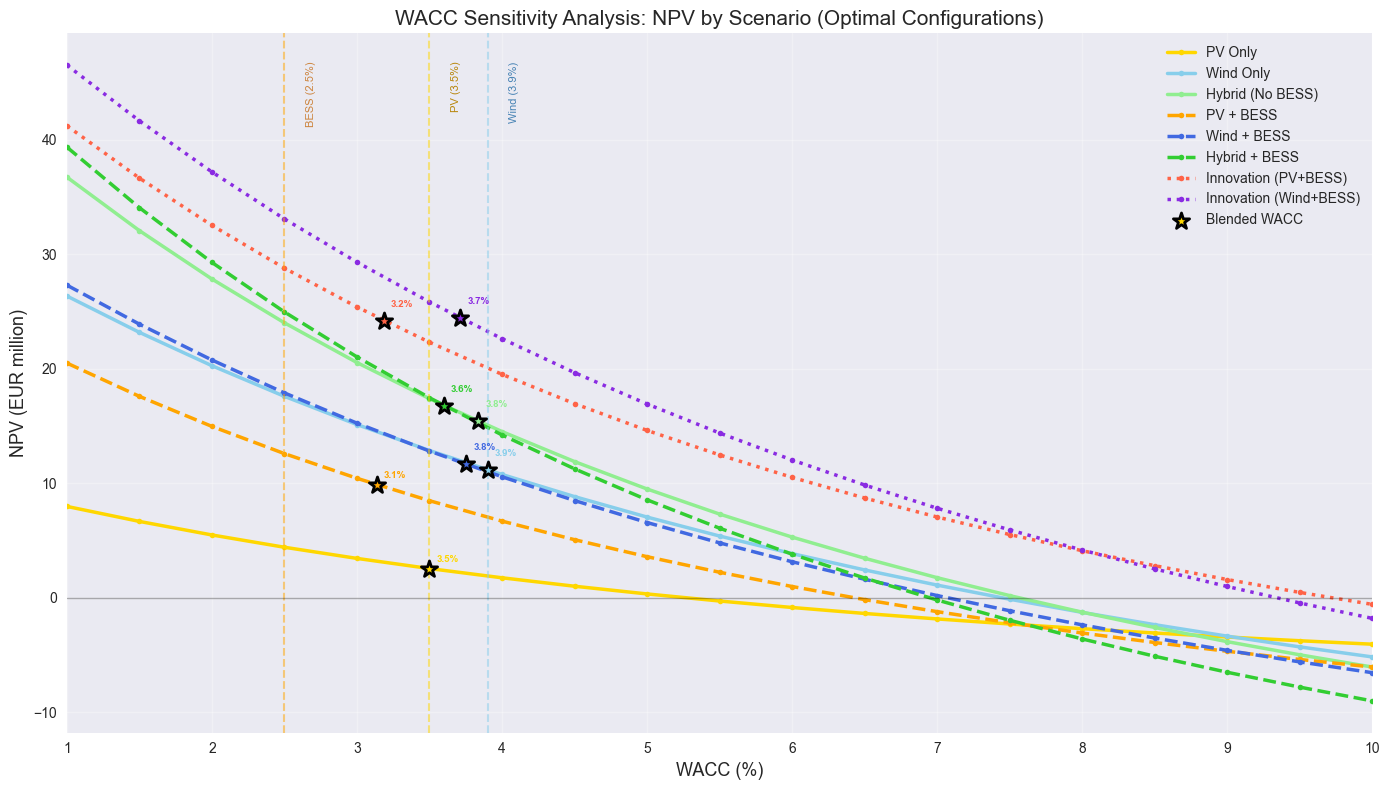


WACC Sensitivity Summary (NPV in EUR million):
      PV Only  Wind Only  Hybrid (No BESS)  PV + BESS  Wind + BESS  Hybrid + BESS  Innovation (PV+BESS)  Innovation (Wind+BESS)
1.0      7.97      26.36             36.75      20.50        27.31          39.37                 41.24                   46.54
1.5      6.66      23.18             32.07      17.59        23.90          34.08                 36.66                   41.67
2.0      5.48      20.27             27.84      14.96        20.77          29.29                 32.53                   37.20
2.5      4.40      17.59             24.02      12.58        17.89          24.96                 28.79                   33.10
3.0      3.43      15.13             20.54      10.43        15.25          21.04                 25.40                   29.32
3.5      2.54      12.86             17.39       8.47        12.81          17.47                 22.32                   25.84
4.0      1.73      10.76             14.51       6.69   

In [91]:
# WACC Sensitivity Analysis for optimal scenario configurations
from config import (
    PROJECT_LIFETIME_YEARS,
    LIFETIME_BESS_YEARS,
    LIFETIME_WIND_YEARS,
    DEGRADATION_PV_PER_YEAR,
    BESS_REPLACEMENT_SHARE,
    CAPEX_BESS_EUR_PER_KWH,
)
from economics import npv as calc_npv

# WACC range to test (1% to 10%)
wacc_range = np.linspace(0.01, 0.10, 19)

# Scenario order for consistent plotting
scenario_order = [
    "PV Only",
    "Wind Only",
    "Hybrid (No BESS)",
    "PV + BESS",
    "Wind + BESS",
    "Hybrid + BESS",
    "Innovation (PV+BESS)",
    "Innovation (Wind+BESS)",
]
scenario_names = [name for name in scenario_order if name in comparison_df.index]

def calculate_npv_for_wacc(row, wacc):
    """
    Calculate NPV for a given WACC using the optimal scenario configuration.
    
    IMPORTANT: Handles different lifetimes for different technologies:
    - PV-only: 30 years with 0.25%/year degradation
    - Wind-only: 25 years, no degradation
    - Hybrid: PV for 30y, Wind for 25y (approximated with blended approach)
    - BESS: Replaced at year 15 (30% of initial CAPEX)
    
    Parameters
    ----------
    row : pd.Series
        Row from the comparison_df DataFrame with scenario configuration.
    wacc : float
        Discount rate to use for NPV calculation.
        
    Returns
    -------
    float
        NPV in EUR.
    """
    capex = row["capex_total_eur"]
    annual_revenue = row.get("annual_revenue_eur", np.nan)
    annual_opex = row.get("annual_opex_total_eur", np.nan)
    
    if pd.isna(annual_revenue) or pd.isna(annual_opex):
        return np.nan
    
    # Get wind share for degradation and lifetime calculation
    s_wind = row.get("s_wind", 0.0)
    if pd.isna(s_wind):
        s_wind = 0.0
    
    # Determine effective project lifetime based on technology mix
    # Wind-only: 25 years, PV-only: 30 years, Hybrid: use project lifetime (30y)
    if s_wind >= 0.999:  # Wind-only
        n_years = LIFETIME_WIND_YEARS
        degradation = 0.0
    elif s_wind <= 0.001:  # PV-only (with or without BESS)
        n_years = PROJECT_LIFETIME_YEARS
        degradation = DEGRADATION_PV_PER_YEAR
    else:  # Hybrid - use project lifetime, wind portion handled separately
        n_years = PROJECT_LIFETIME_YEARS
        degradation = DEGRADATION_PV_PER_YEAR * (1 - s_wind)  # Blended
    
    # Check if scenario has BESS for replacement cost
    bess_power_mw = row.get("bess_power_mw", 0.0)
    bess_energy_mwh = row.get("bess_energy_mwh", 0.0)
    if pd.isna(bess_power_mw):
        bess_power_mw = 0.0
    if pd.isna(bess_energy_mwh):
        bess_energy_mwh = 0.0
    
    has_bess = bess_power_mw > 0
    
    # Calculate BESS replacement cost if applicable
    bess_replacement_cost = 0.0
    if has_bess:
        bess_capex = bess_energy_mwh * 1000 * CAPEX_BESS_EUR_PER_KWH
        bess_replacement_cost = bess_capex * BESS_REPLACEMENT_SHARE
    
    # Build cash flows
    cash_flows = np.zeros(n_years + 1)
    cash_flows[0] = -capex
    
    for y in range(1, n_years + 1):
        # Revenue degrades based on technology mix
        revenue_y = annual_revenue * (1 - degradation) ** (y - 1)
        cash_flows[y] = revenue_y - annual_opex
        
        # BESS replacement at year 15 (only if within project lifetime)
        if has_bess and y == LIFETIME_BESS_YEARS and y <= n_years:
            cash_flows[y] -= bess_replacement_cost
    
    return calc_npv(cash_flows, wacc)


# Calculate NPV for each scenario and WACC value
sensitivity_results = {}
for name in scenario_names:
    row = comparison_df.loc[name]  # Use comparison_df which has annual_revenue_eur
    npvs = [calculate_npv_for_wacc(row, w) for w in wacc_range]
    sensitivity_results[name] = npvs

# Convert to DataFrame for plotting
sensitivity_df = pd.DataFrame(sensitivity_results, index=wacc_range * 100)  # Convert to %

# Plot WACC sensitivity analysis
fig, ax = plt.subplots(figsize=(14, 8))

# Color palette
colors = {
    "PV Only": "#FFD700",
    "Wind Only": "#87CEEB",
    "Hybrid (No BESS)": "#90EE90",
    "PV + BESS": "#FFA500",
    "Wind + BESS": "#4169E1",
    "Hybrid + BESS": "#32CD32",
    "Innovation (PV+BESS)": "#FF6347",
    "Innovation (Wind+BESS)": "#8A2BE2",
}

# Line styles for BESS vs no BESS
line_styles = {
    "PV Only": "-",
    "Wind Only": "-",
    "Hybrid (No BESS)": "-",
    "PV + BESS": "--",
    "Wind + BESS": "--",
    "Hybrid + BESS": "--",
    "Innovation (PV+BESS)": ":",
    "Innovation (Wind+BESS)": ":",
}

for name in scenario_names:
    ax.plot(
        sensitivity_df.index,
        sensitivity_df[name] / 1e6,  # Convert to millions
        label=name,
        color=colors.get(name, "gray"),
        linestyle=line_styles.get(name, "-"),
        linewidth=2.5,
        marker="o",
        markersize=4,
    )

# Add reference lines for technology-specific WACCs
from config import WACC_PV_REAL, WACC_WIND_REAL, WACC_BESS_REAL

ax.axvline(WACC_PV_REAL * 100, color="#FFD700", linestyle="--", alpha=0.5, linewidth=1.5)
ax.axvline(WACC_WIND_REAL * 100, color="#87CEEB", linestyle="--", alpha=0.5, linewidth=1.5)
ax.axvline(WACC_BESS_REAL * 100, color="#FFA500", linestyle="--", alpha=0.5, linewidth=1.5)

# Add text labels for reference WACCs
y_pos = ax.get_ylim()[1] * 0.95
ax.text(WACC_PV_REAL * 100 + 0.15, y_pos, f"PV ({WACC_PV_REAL*100:.1f}%)", fontsize=8, color="#B8860B", rotation=90, va="top")
ax.text(WACC_WIND_REAL * 100 + 0.15, y_pos, f"Wind ({WACC_WIND_REAL*100:.1f}%)", fontsize=8, color="#4682B4", rotation=90, va="top")
ax.text(WACC_BESS_REAL * 100 + 0.15, y_pos, f"BESS ({WACC_BESS_REAL*100:.1f}%)", fontsize=8, color="#CD853F", rotation=90, va="top")

# Calculate and show weighted WACCs for each scenario (as used in original NPV calculation)
def get_weighted_wacc(row):
    """Calculate the weighted WACC based on CAPEX proportions."""
    capex_total = row["capex_total_eur"]
    s_wind = row.get("s_wind", 0.0)
    if pd.isna(s_wind):
        s_wind = 0.0
    
    bess_power_mw = row.get("bess_power_mw", 0.0)
    bess_energy_mwh = row.get("bess_energy_mwh", 0.0)
    if pd.isna(bess_power_mw):
        bess_power_mw = 0.0
    if pd.isna(bess_energy_mwh):
        bess_energy_mwh = 0.0
    
    # Calculate CAPEX components
    from config import CAPEX_PV_EUR_PER_KW, CAPEX_WIND_EUR_PER_KW
    
    alpha = row.get("alpha_tot", row.get("alpha", 1.0))
    if pd.isna(alpha):
        alpha = 1.0
    poi = 10.0  # POI capacity in MW
    
    pv_cap_mw = alpha * poi * (1 - s_wind)
    wind_cap_mw = alpha * poi * s_wind
    
    capex_pv = pv_cap_mw * 1000 * CAPEX_PV_EUR_PER_KW
    capex_wind = wind_cap_mw * 1000 * CAPEX_WIND_EUR_PER_KW
    capex_bess = bess_energy_mwh * 1000 * CAPEX_BESS_EUR_PER_KWH
    
    total_capex = capex_pv + capex_wind + capex_bess
    if total_capex <= 0:
        return WACC_PV_REAL  # Default
    
    # Weighted WACC
    wacc = (capex_pv / total_capex) * WACC_PV_REAL + \
           (capex_wind / total_capex) * WACC_WIND_REAL + \
           (capex_bess / total_capex) * WACC_BESS_REAL
    return wacc

# Add markers for weighted WACCs on each curve
for i, name in enumerate(scenario_names):
    row = comparison_df.loc[name]
    weighted_wacc = get_weighted_wacc(row) * 100  # Convert to %
    
    # Find NPV at weighted WACC (interpolate)
    npv_at_wacc = calculate_npv_for_wacc(row, weighted_wacc / 100) / 1e6
    
    # Plot marker at weighted WACC point (only first one gets label for legend)
    ax.scatter(
        weighted_wacc,
        npv_at_wacc,
        s=150,
        color=colors.get(name, "gray"),
        edgecolors="black",
        linewidths=2,
        zorder=10,
        marker="*",
        label="Blended WACC" if i == 0 else None,
    )
    
    # Add small annotation
    offset_y = 1.0 if npv_at_wacc > 10 else 0.5
    ax.annotate(
        f"{weighted_wacc:.1f}%",
        (weighted_wacc, npv_at_wacc),
        textcoords="offset points",
        xytext=(5, offset_y * 10),
        fontsize=7,
        color=colors.get(name, "gray"),
        fontweight="bold",
    )

# Add zero NPV line
ax.axhline(0, color="black", linestyle="-", alpha=0.3, linewidth=1)

ax.set_xlabel("WACC (%)", fontsize=13)
ax.set_ylabel("NPV (EUR million)", fontsize=13)
ax.set_title("WACC Sensitivity Analysis: NPV by Scenario (Optimal Configurations)", fontsize=15)
ax.legend(loc="upper right", fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, 10)

plt.tight_layout()
plt.savefig(project_root / "figures" / "wacc_sensitivity_analysis.png", dpi=220, bbox_inches="tight")
plt.show()

print("\nWACC Sensitivity Summary (NPV in EUR million):")
print(sensitivity_df.div(1e6).round(2).to_string())

## 1b. Innovation Revenue Split

Stacked bar chart of merchant energy revenue vs. market premium for the two Innovation scenarios.


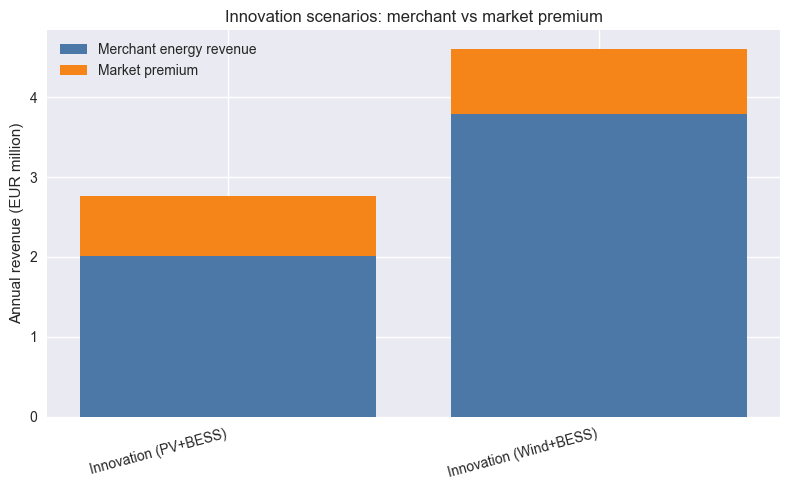

In [92]:
from config import POI_CAPACITY_MW, BESS_ROUNDTRIP_EFF
from simulation_lp import (
    simulate_pv_bess_lp_innovationsausschreibung,
    simulate_pv_wind_bess_lp_innovationsausschreibung,
)

hourly_path = project_root / "data_processed" / "hourly_data.csv"
hourly_df = pd.read_csv(hourly_path, parse_dates=["timestamp"])


def _compute_innovation_revenue_split(row, tech, time_limit_seconds=60):
    eta = np.sqrt(BESS_ROUNDTRIP_EFF)
    params = {
        "bess_cap_mwh": float(row["bess_energy_mwh"]),
        "bess_pwr_mw": float(row["bess_power_mw"]),
        "poi_mw": POI_CAPACITY_MW,
        "eta_ch": eta,
        "eta_dis": eta,
    }

    if tech == "pv_bess":
        pv_capacity_mw = float(row["pv_capacity_mw"])
        sim_df = pd.DataFrame({
            "pv_generation_mw": hourly_df["pv_per_kw"] * pv_capacity_mw,
            "day_ahead_price_eur_mwh": hourly_df["price_eur_per_mwh"],
            "timestamp": hourly_df["timestamp"],
        })
        result = simulate_pv_bess_lp_innovationsausschreibung(
            sim_df,
            params,
            pv_capacity_mw=pv_capacity_mw,
            time_limit_seconds=time_limit_seconds,
            verbose=False,
        )
    else:
        pv_capacity_mw = float(row.get("pv_capacity_mw", 0.0))
        wind_capacity_mw = float(row["wind_capacity_mw"])
        sim_df = pd.DataFrame({
            "pv_generation_mw": hourly_df["pv_per_kw"] * pv_capacity_mw,
            "wind_generation_mw": hourly_df["wind_per_kw"] * wind_capacity_mw,
            "day_ahead_price_eur_mwh": hourly_df["price_eur_per_mwh"],
            "timestamp": hourly_df["timestamp"],
        })
        result = simulate_pv_wind_bess_lp_innovationsausschreibung(
            sim_df,
            params,
            pv_capacity_mw=pv_capacity_mw,
            wind_capacity_mw=wind_capacity_mw,
            time_limit_seconds=time_limit_seconds,
            verbose=False,
        )

    merchant_revenue = (result["export_mw"] * result["price_eur_mwh"]).sum()
    premium_revenue = (result["export_mw"] * result["market_premium_eur_mwh"]).sum()
    return float(merchant_revenue), float(premium_revenue)


labels = []
merchant_vals = []
premium_vals = []

if "Innovation (PV+BESS)" in scenarios:
    row = scenarios["Innovation (PV+BESS)"]
    merchant, premium = _compute_innovation_revenue_split(row, "pv_bess")
    labels.append("Innovation (PV+BESS)")
    merchant_vals.append(merchant)
    premium_vals.append(premium)

if "Innovation (Wind+BESS)" in scenarios:
    row = scenarios["Innovation (Wind+BESS)"]
    merchant, premium = _compute_innovation_revenue_split(row, "wind_bess")
    labels.append("Innovation (Wind+BESS)")
    merchant_vals.append(merchant)
    premium_vals.append(premium)

if labels:
    x = np.arange(len(labels))
    merchant_m = np.array(merchant_vals) / 1e6
    premium_m = np.array(premium_vals) / 1e6

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x, merchant_m, label="Merchant energy revenue", color="#4C78A8")
    ax.bar(x, premium_m, bottom=merchant_m, label="Market premium", color="#F58518")

    ax.set_xticks(x, labels, rotation=15, ha="right")
    ax.set_ylabel("Annual revenue (EUR million)")
    ax.set_title("Innovation scenarios: merchant vs market premium")
    ax.legend()

    plt.tight_layout()
    plt.savefig(project_root / "figures" / "innovation_revenue_split.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No Innovation scenarios available to plot.")



## 2. Visual Comparison

### Scenario-optimal scatter: NPV per MW vs POI utilisation

Bubble plot at scenario-optimal points. Size = CAPEX, shape = BESS vs no BESS, color = merchant vs innovation.


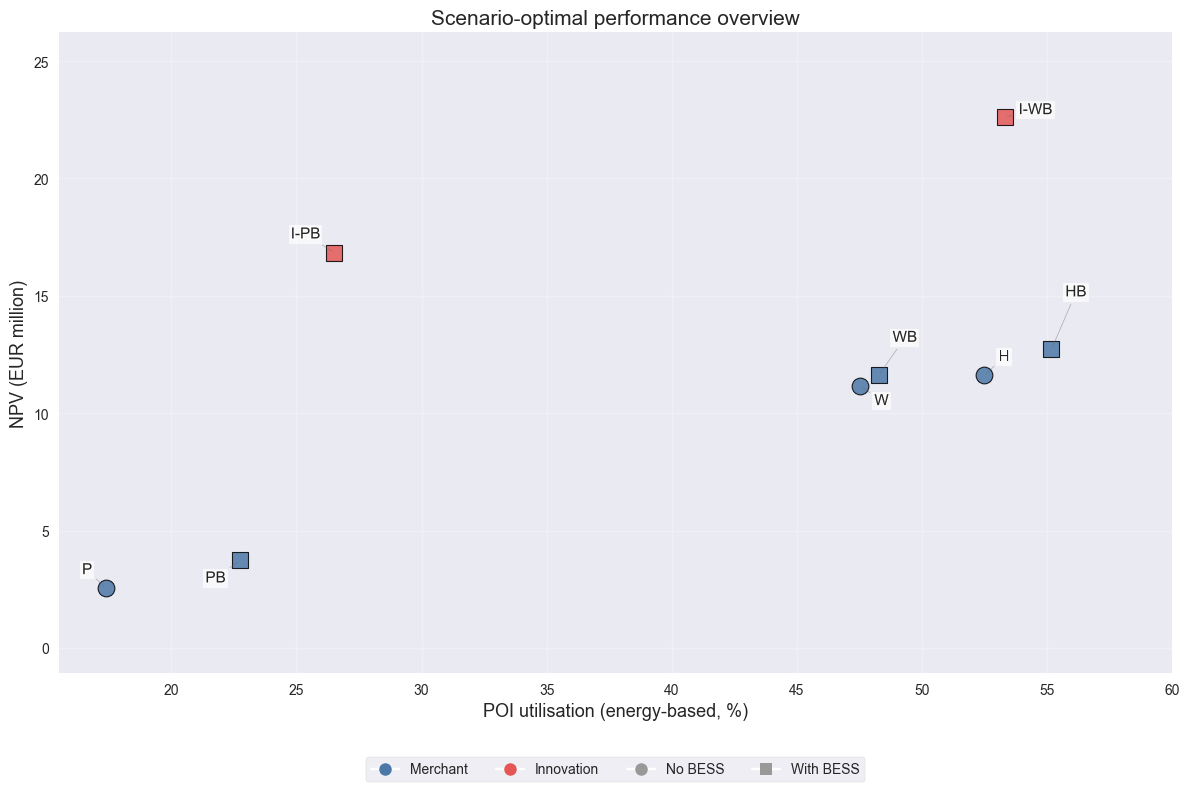

In [93]:
from config import POI_CAPACITY_MW
from matplotlib.lines import Line2D
from matplotlib import patheffects

# Use the scenario-optimal summary from earlier cells
if summary.empty:
    raise ValueError("summary is empty; run the scenario selection cell first.")

plot_df = summary.copy()
plot_df["poi_util_pct"] = plot_df["poi_utilisation"] * 100.0
plot_df["has_bess"] = plot_df["bess_power_mw"] > 0
plot_df["is_innovation"] = plot_df.index.to_series().str.contains("Innovation")

label_map = {
    "PV Only": "P",
    "Wind Only": "W",
    "Hybrid (No BESS)": "H",
    "PV + BESS": "PB",
    "Wind + BESS": "WB",
    "Hybrid + BESS": "HB",
    "Innovation (PV+BESS)": "I-PB",
    "Innovation (Wind+BESS)": "I-WB",
}

# Define offset mappings (in points) for each scenario
# Format: (x_offset_points, y_offset_points)
offset_map = {
    "PV Only": (-10, 8),
    "Wind Only": (10, -6),
    "Hybrid (No BESS)": (10, 8),
    "PV + BESS": (-10, -8),
    "Wind + BESS": (10, 22),
    "Hybrid + BESS": (10, 36),
    "Innovation (PV+BESS)": (-10, 8),
    "Innovation (Wind+BESS)": (10, 0),
}

color_map = {True: "#E45756", False: "#4C78A8"}  # Innovation vs Merchant
marker_map = {True: "s", False: "o"}  # BESS vs no BESS

fig, ax = plt.subplots(figsize=(12, 8))

for idx, (name, row) in enumerate(plot_df.iterrows()):
    x = row["poi_util_pct"]
    y = row["npv_million"]
    
    ax.scatter(
        x,
        y,
        s=145,  # Marker size
        color=color_map[row["is_innovation"]],
        marker=marker_map[row["has_bess"]],
        edgecolor="black",
        linewidth=0.8,
        alpha=0.85,
        zorder=3,
    )

    label = label_map.get(name, name)
    offset = offset_map.get(name, (10, 0))
    
    # Use annotate with fixed offsets and thin leader lines
    ax.annotate(
        label,
        xy=(x, y),
        xytext=offset,
        textcoords="offset points",
        fontsize=11,
        ha="left" if offset[0] >= 0 else "right",
        va="bottom" if offset[1] >= 0 else "top",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5),
        arrowprops=dict(arrowstyle="-", color="#666666", lw=0.5, alpha=0.5),
        zorder=4,
        path_effects=[patheffects.withStroke(linewidth=2, foreground="white", alpha=0.7)],
    )

ax.set_xlabel("POI utilisation (energy-based, %)", fontsize=13)
ax.set_ylabel("NPV (EUR million)", fontsize=13)
ax.set_title("Scenario-optimal performance overview", fontsize=15)
ax.grid(True, alpha=0.25, zorder=0)
ax.set_xlim(left=None, right=60)  # Clip xlim at 60%
ax.margins(y=0.18)

color_handles = [
    Line2D([0], [0], marker="o", color="w", label="Merchant",
           markerfacecolor=color_map[False], markersize=9, markeredgecolor="black"),
    Line2D([0], [0], marker="o", color="w", label="Innovation",
           markerfacecolor=color_map[True], markersize=9, markeredgecolor="black"),
]
shape_handles = [
    Line2D([0], [0], marker=marker_map[False], color="w", label="No BESS",
           markerfacecolor="#999999", markersize=9, markeredgecolor="black"),
    Line2D([0], [0], marker=marker_map[True], color="w", label="With BESS",
           markerfacecolor="#999999", markersize=9, markeredgecolor="black"),
]

# Combine both legends and place below the chart
all_handles = color_handles + shape_handles
ax.legend(
    handles=all_handles,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    frameon=True,
    fontsize=10,
)

plt.tight_layout()
plt.savefig(project_root / "figures" / "scenario_optimal_scatter.png", dpi=220, bbox_inches="tight")
plt.show()



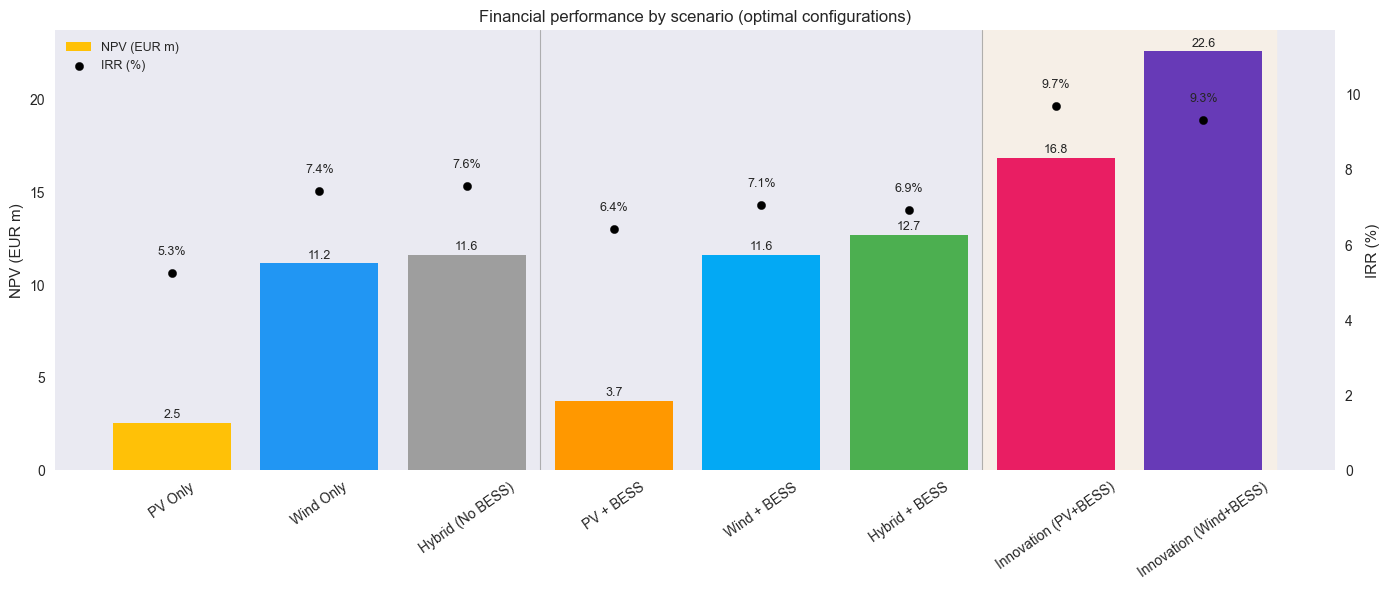

In [94]:
# Financial performance by scenario (optimal configurations)
scenario_order = [
    "PV Only",
    "Wind Only",
    "Hybrid (No BESS)",
    "PV + BESS",
    "Wind + BESS",
    "Hybrid + BESS",
    "Innovation (PV+BESS)",
    "Innovation (Wind+BESS)",
]
scenario_names = [name for name in scenario_order if name in summary.index]

plot_df = summary.loc[scenario_names].copy()
npv_vals = plot_df["npv_million"].astype(float).to_numpy()
irr_vals = plot_df["irr_pct"].astype(float).to_numpy()

# Consistent colors with overview charts
base_colors = ["#FFC107", "#2196F3", "#9E9E9E", "#FF9800", "#03A9F4", "#4CAF50", "#E91E63", "#673AB7"]
color_map = {name: base_colors[i] for i, name in enumerate(scenario_order)}
bar_colors = [color_map.get(name, "#666666") for name in scenario_names]

x = np.arange(len(scenario_names))

fig, ax1 = plt.subplots(figsize=(14, 6))
bars = ax1.bar(x, npv_vals, color=bar_colors, label="NPV (EUR m)")

# NPV labels
for i, v in enumerate(npv_vals):
    if np.isfinite(v):
        ax1.text(i, v + 0.1, f"{v:.1f}", ha="center", va="bottom", fontsize=9)

ax2 = ax1.twinx()
ax2.scatter(x, irr_vals, color="black", s=35, label="IRR (%)", zorder=5)

# IRR labels
for i, v in enumerate(irr_vals):
    if np.isfinite(v):
        ax2.text(i, v + 0.4, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

# Vertical separators between groups
for split_label in ["Hybrid (No BESS)", "Hybrid + BESS"]:
    if split_label in scenario_names:
        split_idx = scenario_names.index(split_label)
        ax1.axvline(split_idx + 0.5, color="#9E9E9E", linewidth=0.8, alpha=0.8)

# Innovation shading
innovation_mask = ["Innovation" in name for name in scenario_names]
if any(innovation_mask):
    idx = np.where(np.array(innovation_mask))[0]
    start = idx.min() - 0.5
    end = idx.max() + 0.5
    ax1.axvspan(start, end, color="#FFF3E0", alpha=0.6, zorder=0)

ax1.set_title("Financial performance by scenario (optimal configurations)")
ax1.set_ylabel("NPV (EUR m)")
ax2.set_ylabel("IRR (%)")
ax1.set_xlabel("")
ax1.set_xticks(x)
ax1.set_xticklabels(scenario_names, rotation=35)
ax1.grid(False)
ax2.grid(False)

npv_min = float(np.nanmin(npv_vals)) if np.any(np.isfinite(npv_vals)) else 0.0
ax1.set_ylim(min(0.0, npv_min - 0.5), None)
ax2.set_ylim(0, max(1.0, float(np.nanmax(irr_vals)) + 2.0))

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()


### LCOE comparison

Levelized cost of energy across the scenario-optimal configurations.


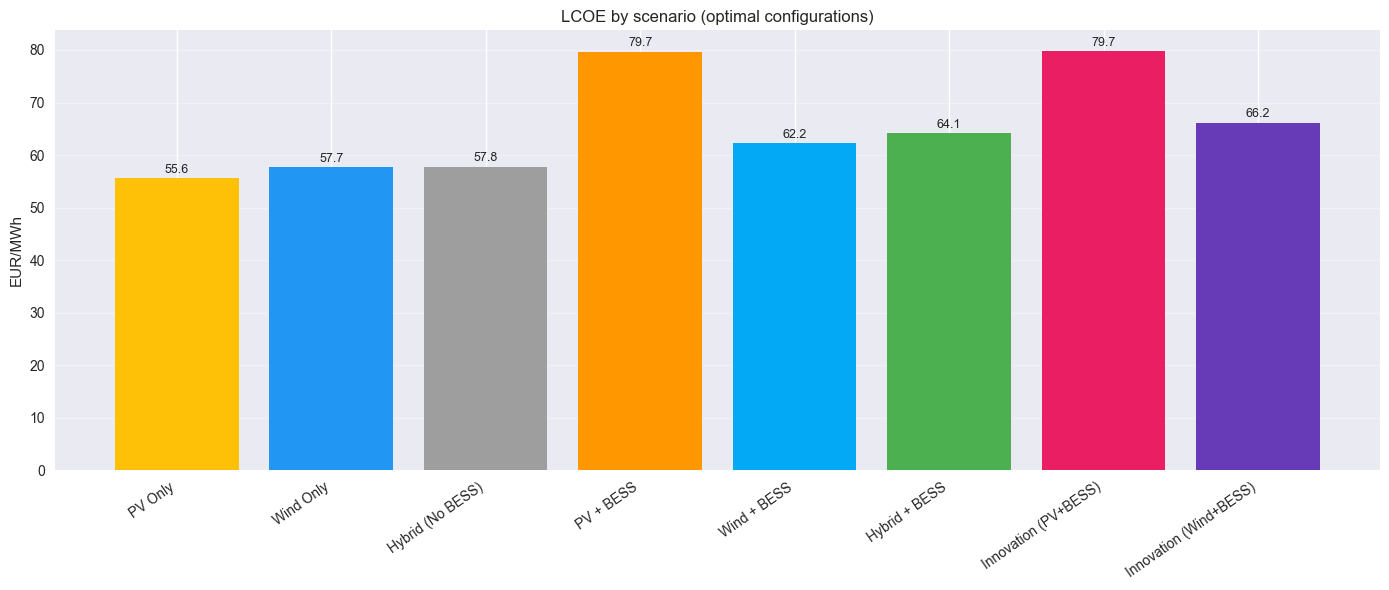

In [95]:
# LCOE comparison across scenarios
from config import (
    LIFETIME_PV_YEARS,
    LIFETIME_WIND_YEARS,
    LIFETIME_BESS_YEARS,
    PROJECT_LIFETIME_YEARS,
    WACC_PV_REAL,
    WACC_WIND_REAL,
    DEGRADATION_PV_PER_YEAR,
    DEGRADATION_WIND_PER_YEAR,
    OPEX_PV_EUR_PER_KW_PER_YEAR,
    OPEX_WIND_EUR_PER_KW_PER_YEAR,
    OPEX_BESS_EUR_PER_KW_PER_YEAR,
    BESS_REPLACEMENT_SHARE,
)


def _get_discount_rate(row):
    wacc = row.get("wacc", np.nan)
    if pd.notna(wacc):
        return float(wacc)
    s_wind = row.get("s_wind", np.nan)
    if pd.notna(s_wind):
        if np.isclose(s_wind, 1.0):
            return WACC_WIND_REAL
        if np.isclose(s_wind, 0.0):
            return WACC_PV_REAL
    return WACC_PV_REAL


def _get_generation_split(row):
    total = row.get("annual_export_mwh_total", np.nan)
    if pd.isna(total):
        total = row.get("annual_export_mwh", np.nan)

    pv = row.get("annual_export_mwh_pv", np.nan)
    wind = row.get("annual_export_mwh_wind", np.nan)

    if pd.isna(total):
        if pd.notna(pv) or pd.notna(wind):
            total = np.nansum([pv, wind])
        else:
            return np.nan, np.nan, np.nan

    if pd.isna(pv) and pd.isna(wind):
        s_wind = row.get("s_wind", np.nan)
        if pd.notna(s_wind):
            wind = total * float(s_wind)
            pv = total - wind
        else:
            pv = total
            wind = 0.0
    else:
        pv = 0.0 if pd.isna(pv) else float(pv)
        wind = 0.0 if pd.isna(wind) else float(wind)
        residual = total - (pv + wind)
        if residual > 0 and (pv + wind) > 0:
            pv += residual * (pv / (pv + wind))
            wind += residual * (wind / (pv + wind))
        elif residual > 0 and (pv + wind) == 0:
            s_wind = row.get("s_wind", np.nan)
            if pd.notna(s_wind):
                wind = total * float(s_wind)
                pv = total - wind
            else:
                pv = total
                wind = 0.0

    return pv, wind, total


def _get_opex_components(row):
    pv = row.get("annual_opex_pv_eur", np.nan)
    wind = row.get("annual_opex_wind_eur", np.nan)
    bess = row.get("annual_opex_bess_eur", np.nan)

    if pd.isna(pv):
        pv_cap = row.get("pv_capacity_mw", np.nan)
        cap_mw = row.get("capacity_mw", np.nan)
        if pd.notna(pv_cap):
            pv = float(pv_cap) * 1000.0 * OPEX_PV_EUR_PER_KW_PER_YEAR
        elif pd.notna(cap_mw) and np.isclose(row.get("s_wind", 0.0), 0.0):
            pv = float(cap_mw) * 1000.0 * OPEX_PV_EUR_PER_KW_PER_YEAR

    if pd.isna(wind):
        wind_cap = row.get("wind_capacity_mw", np.nan)
        cap_mw = row.get("capacity_mw", np.nan)
        if pd.notna(wind_cap):
            wind = float(wind_cap) * 1000.0 * OPEX_WIND_EUR_PER_KW_PER_YEAR
        elif pd.notna(cap_mw) and np.isclose(row.get("s_wind", 0.0), 1.0):
            wind = float(cap_mw) * 1000.0 * OPEX_WIND_EUR_PER_KW_PER_YEAR

    if pd.isna(bess):
        bess_power = row.get("bess_power_mw", np.nan)
        if pd.notna(bess_power) and float(bess_power) > 0:
            bess = float(bess_power) * 1000.0 * OPEX_BESS_EUR_PER_KW_PER_YEAR

    total = row.get("annual_opex_total_eur", np.nan)
    return pv, wind, bess, total


def _compute_lcoe(row):
    capex = row.get("capex_total_eur", np.nan)
    if pd.isna(capex) or capex <= 0:
        return np.nan

    discount_rate = _get_discount_rate(row)
    pv_gen, wind_gen, total_gen = _get_generation_split(row)
    if pd.isna(total_gen) or total_gen <= 0:
        return np.nan

    pv_opex, wind_opex, bess_opex, total_opex = _get_opex_components(row)
    has_component_opex = pd.notna(pv_opex) or pd.notna(wind_opex) or pd.notna(bess_opex)

    total_discounted_cost = float(capex)
    total_discounted_generation = 0.0

    for year in range(1, PROJECT_LIFETIME_YEARS + 1):
        gen_y = 0.0
        if pv_gen > 0 and year <= LIFETIME_PV_YEARS:
            gen_y += pv_gen * (1 - DEGRADATION_PV_PER_YEAR) ** (year - 1)
        if wind_gen > 0 and year <= LIFETIME_WIND_YEARS:
            gen_y += wind_gen * (1 - DEGRADATION_WIND_PER_YEAR) ** (year - 1)
        if gen_y > 0:
            total_discounted_generation += gen_y / (1 + discount_rate) ** year

        opex_y = 0.0
        if pd.notna(pv_opex) and pv_opex > 0 and year <= LIFETIME_PV_YEARS:
            opex_y += pv_opex
        if pd.notna(wind_opex) and wind_opex > 0 and year <= LIFETIME_WIND_YEARS:
            opex_y += wind_opex
        if pd.notna(bess_opex) and bess_opex > 0 and year <= PROJECT_LIFETIME_YEARS:
            opex_y += bess_opex
        if not has_component_opex and pd.notna(total_opex) and total_opex > 0:
            opex_y = total_opex

        total_discounted_cost += opex_y / (1 + discount_rate) ** year

    capex_bess = row.get("capex_bess_eur", np.nan)
    if pd.notna(capex_bess) and capex_bess > 0:
        total_discounted_cost += (
            BESS_REPLACEMENT_SHARE * capex_bess / (1 + discount_rate) ** LIFETIME_BESS_YEARS
        )

    if total_discounted_generation > 0:
        return total_discounted_cost / total_discounted_generation
    return np.nan


lcoe_df = comparison_df.copy()
lcoe_df["lcoe_eur_per_mwh"] = lcoe_df.apply(_compute_lcoe, axis=1)

scenario_order = [
    "PV Only",
    "Wind Only",
    "Hybrid (No BESS)",
    "PV + BESS",
    "Wind + BESS",
    "Hybrid + BESS",
    "Innovation (PV+BESS)",
    "Innovation (Wind+BESS)",
]
scenario_names = [name for name in scenario_order if name in lcoe_df.index]

plot_df = lcoe_df.loc[scenario_names]
lcoe_vals = plot_df["lcoe_eur_per_mwh"].astype(float).to_numpy()

base_colors = ["#FFC107", "#2196F3", "#9E9E9E", "#FF9800", "#03A9F4", "#4CAF50", "#E91E63", "#673AB7"]
color_map = {name: base_colors[i] for i, name in enumerate(scenario_order)}
bar_colors = [color_map.get(name, "#666666") for name in scenario_names]

x = np.arange(len(scenario_names))
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(x, lcoe_vals, color=bar_colors)

for i, v in enumerate(lcoe_vals):
    if np.isfinite(v):
        ax.text(i, v + 0.5, f"{v:.1f}", ha="center", va="bottom", fontsize=9)

ax.set_title("LCOE by scenario (optimal configurations)")
ax.set_ylabel("EUR/MWh")
ax.set_xticks(x)
ax.set_xticklabels(scenario_names, rotation=35, ha="right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / "figures" / "comparison_lcoe.png", dpi=200, bbox_inches="tight")
plt.show()


/var/folders/2p/bk483h253013txglty1ym51m0000gn/T/ipykernel_8559/3897801243.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_df.index, y="npv_million", data=plot_df, ax=axes[0], palette=colors)
/var/folders/2p/bk483h253013txglty1ym51m0000gn/T/ipykernel_8559/3897801243.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_df.index, y="irr_pct", data=plot_df, ax=axes[1], palette=colors)


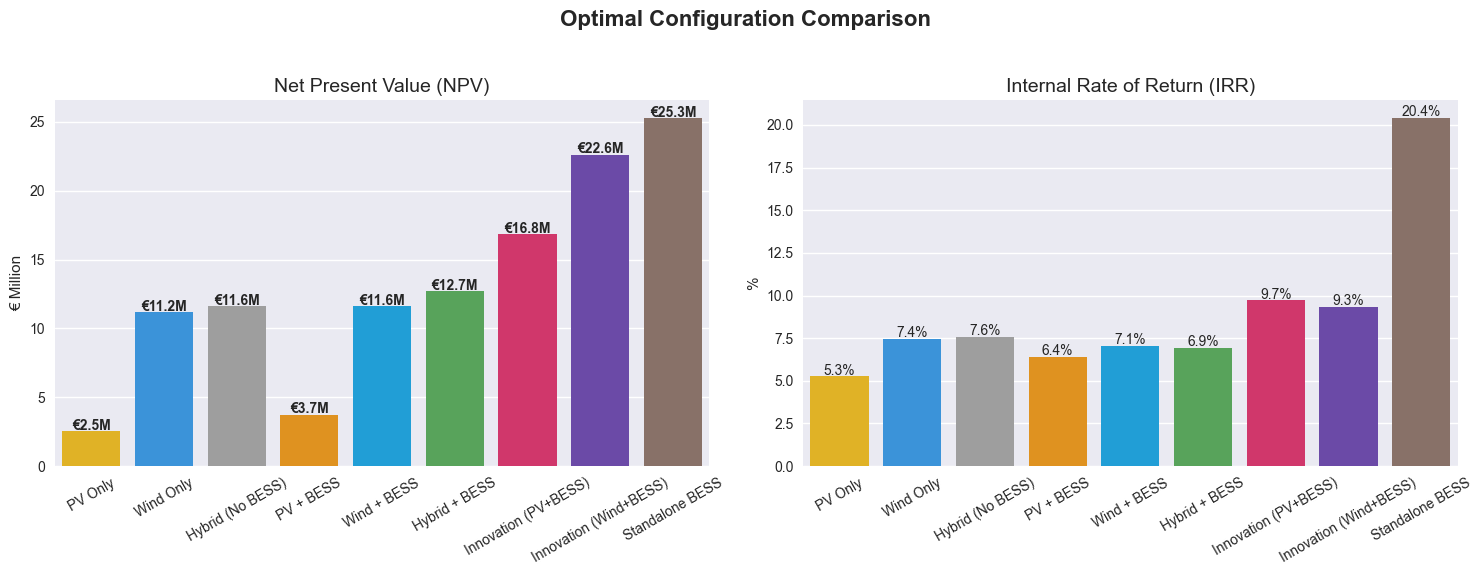

/var/folders/2p/bk483h253013txglty1ym51m0000gn/T/ipykernel_8559/3897801243.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y="poi_utilisation_pct", data=summary, ax=axes[0], palette=summary_colors)
/var/folders/2p/bk483h253013txglty1ym51m0000gn/T/ipykernel_8559/3897801243.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y="curtailment_pct", data=summary, ax=axes[1], palette=summary_colors)


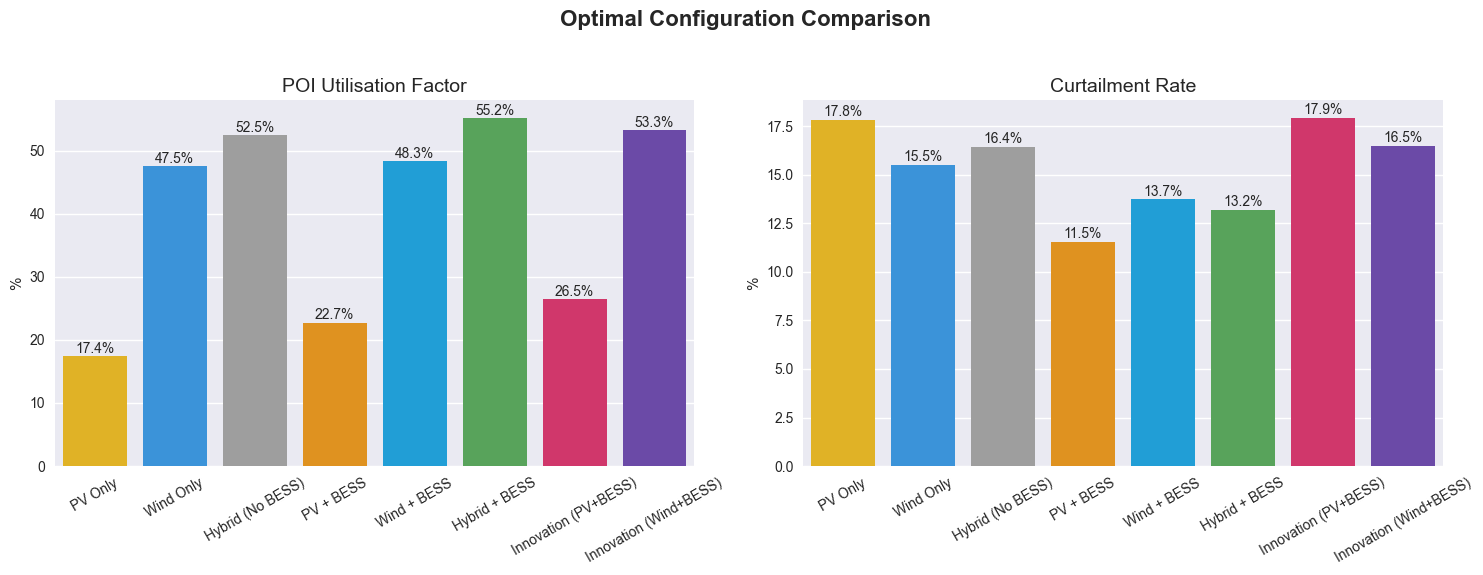

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Optimal Configuration Comparison", fontsize=16, fontweight="bold")

from config import (
    CAPEX_BESS_EUR_PER_KWH,
    OPEX_BESS_EUR_PER_KW_PER_YEAR,
    LIFETIME_BESS_YEARS,
    BESS_REPLACEMENT_SHARE,
    PROJECT_LIFETIME_YEARS,
    WACC_BESS_REAL,
    STANDALONE_BESS_ANNUAL_REVENUE_EUR_PER_MW,
    STANDALONE_BESS_POWER_MW,
)
from economics import npv, irr

# Standalone BESS metrics for comparison
bess_duration_h = 2.0
bess_power_mw = STANDALONE_BESS_POWER_MW
bess_energy_mwh = bess_power_mw * bess_duration_h
annual_revenue_eur = STANDALONE_BESS_ANNUAL_REVENUE_EUR_PER_MW * bess_power_mw
bess_capex_eur = bess_energy_mwh * 1000.0 * CAPEX_BESS_EUR_PER_KWH
bess_opex_eur_per_year = bess_power_mw * 1000.0 * OPEX_BESS_EUR_PER_KW_PER_YEAR
replacement_cost_eur = bess_capex_eur * BESS_REPLACEMENT_SHARE
replacement_years = [
    year
    for year in range(LIFETIME_BESS_YEARS, PROJECT_LIFETIME_YEARS, LIFETIME_BESS_YEARS)
]

cash_flows = np.zeros(PROJECT_LIFETIME_YEARS + 1)
cash_flows[0] = -bess_capex_eur
for year in range(1, PROJECT_LIFETIME_YEARS + 1):
    cash_flows[year] = annual_revenue_eur - bess_opex_eur_per_year
    if year in replacement_years:
        cash_flows[year] -= replacement_cost_eur

standalone_npv = npv(cash_flows, WACC_BESS_REAL)
try:
    standalone_irr = irr(cash_flows)
except ValueError:
    standalone_irr = np.nan

plot_df = summary.copy()
plot_df.loc["Standalone BESS", "npv_million"] = standalone_npv / 1e6
plot_df.loc["Standalone BESS", "irr_pct"] = standalone_irr * 100

scenarios_list = plot_df.index
# Colors for: PV Only, Wind Only, Hybrid (No BESS), PV+BESS, Wind+BESS, Hybrid+BESS,
# Inn(PV+BESS), Inn(Wind+BESS), Standalone BESS
# Ensure we have enough colors for the actual number of scenarios
base_colors = [
    "#FFC107",
    "#2196F3",
    "#9E9E9E",
    "#FF9800",
    "#03A9F4",
    "#4CAF50",
    "#E91E63",
    "#673AB7",
    "#8D6E63",
]
colors = base_colors[:len(scenarios_list)]

# 1. NPV
sns.barplot(x=plot_df.index, y="npv_million", data=plot_df, ax=axes[0], palette=colors)
axes[0].set_title("Net Present Value (NPV)", fontsize=14)
axes[0].set_ylabel("€ Million")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(plot_df["npv_million"]):
    axes[0].text(i, v + 0.1, f"€{v:.1f}M", ha="center", fontweight="bold")

# 2. IRR
sns.barplot(x=plot_df.index, y="irr_pct", data=plot_df, ax=axes[1], palette=colors)
axes[1].set_title("Internal Rate of Return (IRR)", fontsize=14)
axes[1].set_ylabel("%")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)
for i, v in enumerate(plot_df["irr_pct"]):
    axes[1].text(i, v + 0.1, f"{v:.1f}%", ha="center")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(project_root / "figures" / "comparison_dashboard_financial.png")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Optimal Configuration Comparison", fontsize=16, fontweight="bold")

summary_colors = base_colors[:len(summary.index)]

# 3. POI Utilisation
sns.barplot(x=summary.index, y="poi_utilisation_pct", data=summary, ax=axes[0], palette=summary_colors)
axes[0].set_title("POI Utilisation Factor", fontsize=14)
axes[0].set_ylabel("%")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(summary["poi_utilisation_pct"]):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center")

# 4. Curtailment
sns.barplot(x=summary.index, y="curtailment_pct", data=summary, ax=axes[1], palette=summary_colors)
axes[1].set_title("Curtailment Rate", fontsize=14)
axes[1].set_ylabel("%")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)
for i, v in enumerate(summary["curtailment_pct"]):
    axes[1].text(i, v + 0.2, f"{v:.1f}%", ha="center")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(project_root / "figures" / "comparison_dashboard_operational.png")
plt.show()


## 2b. NPV Heatmaps (Overplanting vs Gamma)


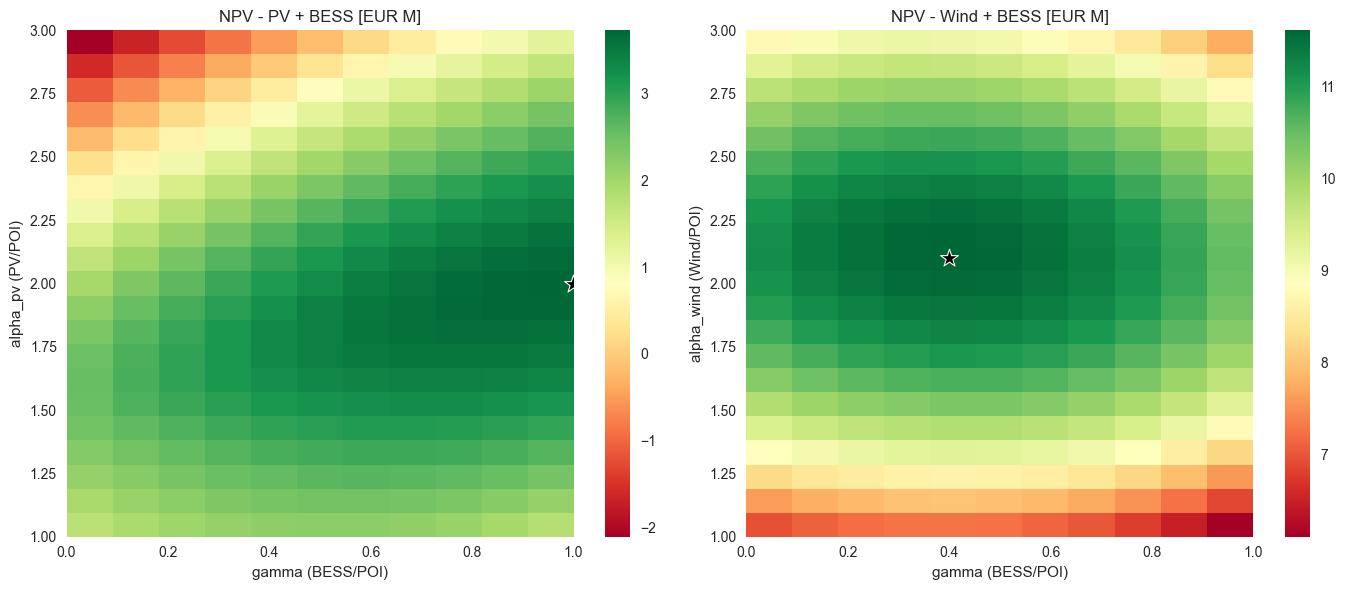

In [97]:
# NPV heatmaps for PV + BESS and Wind + BESS
if df_pv_bess.empty or df_wind_bess.empty:
    print("Missing PV+BESS or Wind+BESS results for heatmaps.")
else:
    pv_heat = df_pv_bess.copy()
    wind_heat = df_wind_bess.copy()
    if "s_wind" in wind_heat.columns:
        wind_only = wind_heat[np.isclose(wind_heat["s_wind"], 1.0)]
        if not wind_only.empty:
            wind_heat = wind_only

    pv_pivot = pv_heat.pivot_table(index="alpha_pv", columns="gamma", values="npv_eur", aggfunc="mean")
    wind_pivot = wind_heat.pivot_table(index="alpha_tot", columns="gamma", values="npv_eur", aggfunc="mean")

    pv_pivot = pv_pivot.sort_index()
    wind_pivot = wind_pivot.sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    pv_gamma = pv_pivot.columns.to_numpy()
    pv_alpha = pv_pivot.index.to_numpy()
    im0 = axes[0].imshow(
        pv_pivot.values / 1e6,
        cmap="RdYlGn",
        aspect="auto",
        origin="lower",
        extent=[pv_gamma.min(), pv_gamma.max(), pv_alpha.min(), pv_alpha.max()],
    )
    pv_best = pv_heat.loc[pv_heat["npv_eur"].idxmax()]
    axes[0].scatter(
        pv_best["gamma"],
        pv_best["alpha_pv"],
        marker="*",
        s=180,
        c="black",
        edgecolors="white",
        linewidths=0.8,
        zorder=5,
    )
    axes[0].set_xlabel("gamma (BESS/POI)")
    axes[0].set_ylabel("alpha_pv (PV/POI)")
    axes[0].set_title("NPV - PV + BESS [EUR M]")
    axes[0].grid(False)
    plt.colorbar(im0, ax=axes[0])

    wind_gamma = wind_pivot.columns.to_numpy()
    wind_alpha = wind_pivot.index.to_numpy()
    im1 = axes[1].imshow(
        wind_pivot.values / 1e6,
        cmap="RdYlGn",
        aspect="auto",
        origin="lower",
        extent=[wind_gamma.min(), wind_gamma.max(), wind_alpha.min(), wind_alpha.max()],
    )
    wind_best = wind_heat.loc[wind_heat["npv_eur"].idxmax()]
    axes[1].scatter(
        wind_best["gamma"],
        wind_best["alpha_tot"],
        marker="*",
        s=180,
        c="black",
        edgecolors="white",
        linewidths=0.8,
        zorder=5,
    )
    axes[1].set_xlabel("gamma (BESS/POI)")
    axes[1].set_ylabel("alpha_wind (Wind/POI)")
    axes[1].set_title("NPV - Wind + BESS [EUR M]")
    axes[1].grid(False)
    plt.colorbar(im1, ax=axes[1])

    plt.tight_layout()
    plt.show()


## 3. Detailed Parameter Comparison

Let's look at the physical sizing of these optimal setups.

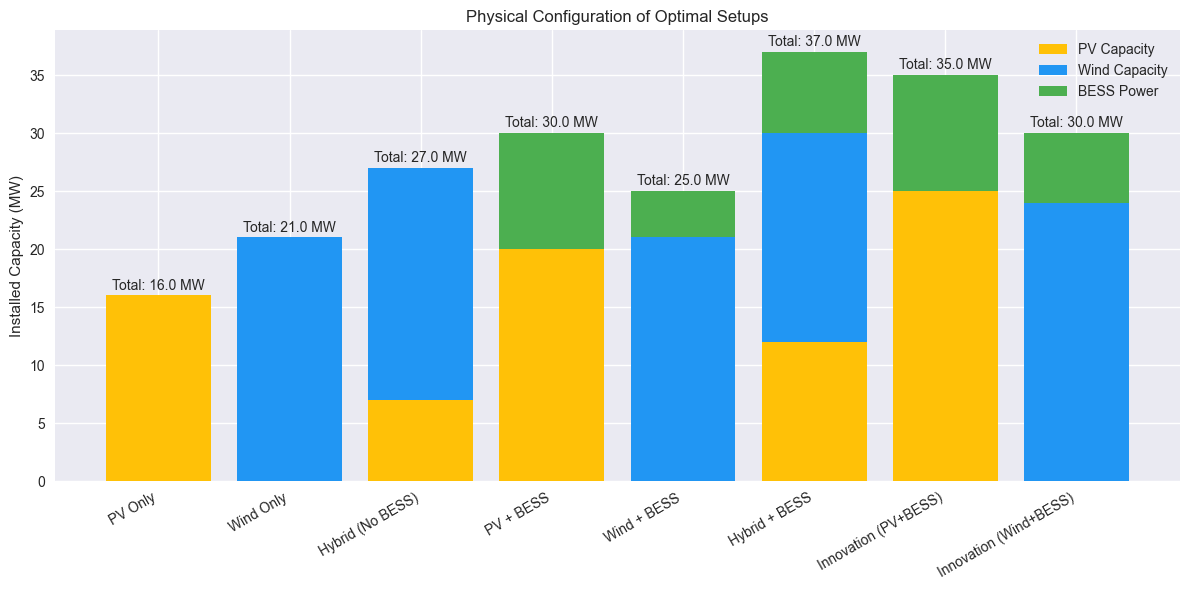

In [98]:
# Prepare data for stacked bar chart of capacities
# We need to calculate MW for each component
plot_df = summary.copy()
# Re-calculate capacities (alpha_tot * poi_cap * shares)
# Assuming POI = 10 MW (Standard in this project, but safer to derive)
poi_cap = 10.0 # Standard assumption

plot_df['pv_mw'] = plot_df['alpha_tot'] * poi_cap * (1 - plot_df['s_wind'])
plot_df['wind_mw'] = plot_df['alpha_tot'] * poi_cap * plot_df['s_wind']
# bess_power_mw is already in MW

fig, ax = plt.subplots(figsize=(12, 6))

scenarios = plot_df.index

ax.bar(scenarios, plot_df['pv_mw'], label='PV Capacity', color='#FFC107')
ax.bar(scenarios, plot_df['wind_mw'], bottom=plot_df['pv_mw'], label='Wind Capacity', color='#2196F3')
ax.bar(scenarios, plot_df['bess_power_mw'], bottom=plot_df['pv_mw'] + plot_df['wind_mw'], label='BESS Power', color='#4CAF50')

ax.set_ylabel("Installed Capacity (MW)")
ax.set_title("Physical Configuration of Optimal Setups")
ax.legend()
plt.xticks(rotation=30, ha='right')

# Add labels
for i, (idx, row) in enumerate(plot_df.iterrows()):
    total_h = row['pv_mw'] + row['wind_mw'] + row['bess_power_mw']
    ax.text(i, total_h + 0.5, f"Total: {total_h:.1f} MW", ha='center')

plt.tight_layout()
plt.savefig(project_root / "figures" / "comparison_capacities.png")
plt.show()

## 4. Duration Curves

- POI export duration curve (sorted hourly export)
- Curtailment duration curve (PV vs wind split for hybrid)


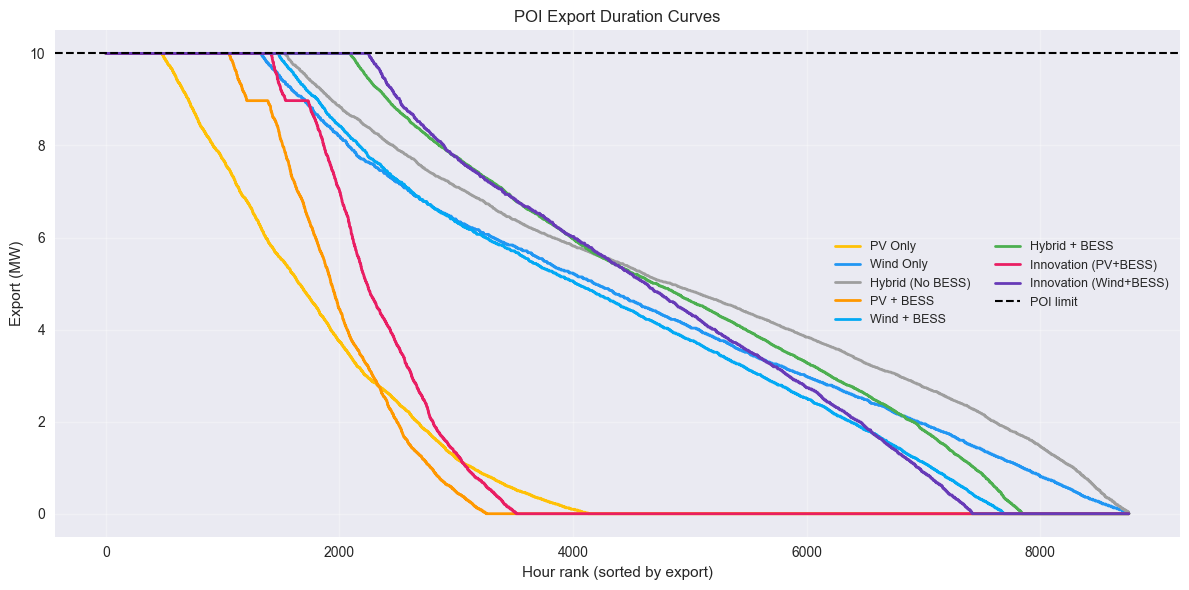

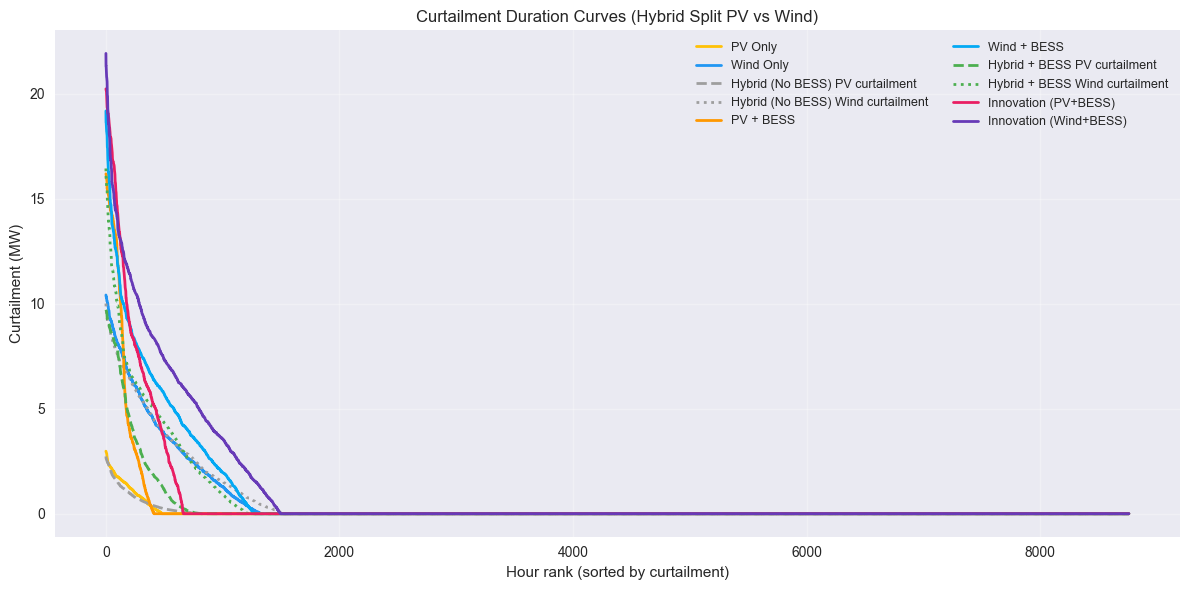

In [99]:
# Load hourly profiles
hourly_path = project_root / "data_processed" / "hourly_data.csv"
hourly_df = pd.read_csv(hourly_path)
hourly_df["timestamp"] = pd.to_datetime(hourly_df["timestamp"])

from config import POI_CAPACITY_MW, BESS_ROUNDTRIP_EFF
from simulation import simulate_export_pv, simulate_export_wind, simulate_export_hybrid
from simulation_lp import (
    simulate_pv_bess_lp,
    simulate_pv_bess_lp_innovationsausschreibung,
    simulate_pv_wind_bess_lp,
    simulate_pv_wind_bess_lp_innovationsausschreibung,
)

lp_time_limit_seconds = 60
eta_ch = np.sqrt(BESS_ROUNDTRIP_EFF)
eta_dis = np.sqrt(BESS_ROUNDTRIP_EFF)


def _build_lp_params(bess_power_mw, bess_energy_mwh, poi_capacity_mw):
    return {
        "bess_cap_mwh": bess_energy_mwh,
        "bess_pwr_mw": bess_power_mw,
        "poi_mw": poi_capacity_mw,
        "eta_ch": eta_ch,
        "eta_dis": eta_dis,
    }


def _build_lp_df(hourly_df, pv_capacity_mw, wind_capacity_mw):
    return pd.DataFrame({
        "timestamp": hourly_df["timestamp"],
        "pv_generation_mw": hourly_df["pv_per_kw"] * pv_capacity_mw,
        "wind_generation_mw": hourly_df["wind_per_kw"] * wind_capacity_mw,
        "day_ahead_price_eur_mwh": hourly_df["price_eur_per_mwh"],
    })


def _dispatch_for_scenario(name, row):
    pv_capacity_mw = row["alpha_tot"] * POI_CAPACITY_MW * (1 - row["s_wind"])
    wind_capacity_mw = row["alpha_tot"] * POI_CAPACITY_MW * row["s_wind"]
    bess_power_mw = row["bess_power_mw"]
    bess_energy_mwh = row["bess_energy_mwh"]

    has_pv = pv_capacity_mw > 0
    has_wind = wind_capacity_mw > 0
    has_bess = bess_power_mw > 0 and bess_energy_mwh > 0

    if has_bess:
        params = _build_lp_params(bess_power_mw, bess_energy_mwh, POI_CAPACITY_MW)
        if has_wind:
            lp_df = _build_lp_df(hourly_df, pv_capacity_mw, wind_capacity_mw)
            if "Innovation" in name:
                return simulate_pv_wind_bess_lp_innovationsausschreibung(
                    lp_df,
                    params,
                    pv_capacity_mw=pv_capacity_mw,
                    wind_capacity_mw=wind_capacity_mw,
                    time_limit_seconds=lp_time_limit_seconds,
                    verbose=False,
                )
            return simulate_pv_wind_bess_lp(
                lp_df,
                params,
                time_limit_seconds=lp_time_limit_seconds,
                verbose=False,
            )

        lp_df = pd.DataFrame({
            "timestamp": hourly_df["timestamp"],
            "pv_generation_mw": hourly_df["pv_per_kw"] * pv_capacity_mw,
            "day_ahead_price_eur_mwh": hourly_df["price_eur_per_mwh"],
        })
        if "Innovation" in name:
            return simulate_pv_bess_lp_innovationsausschreibung(
                lp_df,
                params,
                pv_capacity_mw=pv_capacity_mw,
                time_limit_seconds=lp_time_limit_seconds,
                verbose=False,
            )
        return simulate_pv_bess_lp(
            lp_df,
            params,
            time_limit_seconds=lp_time_limit_seconds,
            verbose=False,
        )

    if has_pv and has_wind:
        result = simulate_export_hybrid(
            hourly_df,
            wind_capacity_mw=wind_capacity_mw,
            pv_capacity_mw=pv_capacity_mw,
            poi_capacity_mw=POI_CAPACITY_MW,
        )
        pv_gen = hourly_df["pv_per_kw"] * pv_capacity_mw
        wind_gen = hourly_df["wind_per_kw"] * wind_capacity_mw
        total_gen = pv_gen + wind_gen
        total_gen_safe = total_gen.replace(0, np.nan)
        result["curtailment_pv_mw"] = result["curtailment_mw"] * (pv_gen / total_gen_safe)
        result["curtailment_wind_mw"] = result["curtailment_mw"] * (wind_gen / total_gen_safe)
        result[["curtailment_pv_mw", "curtailment_wind_mw"]] = result[
            ["curtailment_pv_mw", "curtailment_wind_mw"]
        ].fillna(0.0)
        return result

    if has_wind:
        return simulate_export_wind(
            hourly_df,
            wind_capacity_mw=wind_capacity_mw,
            poi_capacity_mw=POI_CAPACITY_MW,
        )

    return simulate_export_pv(
        hourly_df,
        pv_capacity_mw=pv_capacity_mw,
        poi_capacity_mw=POI_CAPACITY_MW,
    )


# Build dispatch curves for each scenario
if summary.empty:
    raise ValueError("summary is empty; run the scenario selection cells first.")

dispatch_results = {}
scenario_meta = {}

for name in summary.index:
    row = summary.loc[name]
    try:
        dispatch = _dispatch_for_scenario(name, row)
    except Exception as exc:
        print(f"Warning: skipped {name} due to {exc}")
        continue

    dispatch_results[name] = dispatch
    scenario_meta[name] = {
        "has_pv": (row["alpha_tot"] * (1 - row["s_wind"])) > 0,
        "has_wind": (row["alpha_tot"] * row["s_wind"]) > 0,
    }


def _duration_curve(values):
    return np.sort(np.asarray(values, dtype=float))[::-1]


# Plot export duration curves
scenario_names = list(dispatch_results.keys())
base_colors = [
    "#FFC107",
    "#2196F3",
    "#9E9E9E",
    "#FF9800",
    "#03A9F4",
    "#4CAF50",
    "#E91E63",
    "#673AB7",
]
scenario_colors = {
    name: base_colors[i % len(base_colors)] for i, name in enumerate(scenario_names)
}

fig, ax = plt.subplots(figsize=(12, 6))
for name in scenario_names:
    export_curve = _duration_curve(dispatch_results[name]["export_mw"])
    ax.plot(
        np.arange(1, len(export_curve) + 1),
        export_curve,
        label=name,
        color=scenario_colors[name],
        linewidth=2,
    )

ax.axhline(
    POI_CAPACITY_MW,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="POI limit",
)
ax.set_title("POI Export Duration Curves")
ax.set_xlabel("Hour rank (sorted by export)")
ax.set_ylabel("Export (MW)")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


# Plot curtailment duration curves with hybrid split
fig, ax = plt.subplots(figsize=(12, 6))
for name in scenario_names:
    result = dispatch_results[name]
    meta = scenario_meta[name]
    if meta["has_pv"] and meta["has_wind"]:
        if "curtailment_pv_mw" in result.columns:
            pv_values = result["curtailment_pv_mw"]
            wind_values = result["curtailment_wind_mw"]
        else:
            pv_values = result["curtailment_mw"]
            wind_values = result["curtailment_mw"]
        pv_curve = _duration_curve(pv_values)
        wind_curve = _duration_curve(wind_values)
        ax.plot(
            np.arange(1, len(pv_curve) + 1),
            pv_curve,
            label=f"{name} PV curtailment",
            color=scenario_colors[name],
            linestyle="--",
            linewidth=2,
        )
        ax.plot(
            np.arange(1, len(wind_curve) + 1),
            wind_curve,
            label=f"{name} Wind curtailment",
            color=scenario_colors[name],
            linestyle=":",
            linewidth=2,
        )
    else:
        curtail_curve = _duration_curve(result["curtailment_mw"])
        ax.plot(
            np.arange(1, len(curtail_curve) + 1),
            curtail_curve,
            label=name,
            color=scenario_colors[name],
            linewidth=2,
        )

ax.set_title("Curtailment Duration Curves (Hybrid Split PV vs Wind)")
ax.set_xlabel("Hour rank (sorted by curtailment)")
ax.set_ylabel("Curtailment (MW)")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


## 4b. Utilisation & Export Availability

Summary of utilisation and congestion-style metrics across the optimal setups.

C. Curtailment summary (single panel, no export).


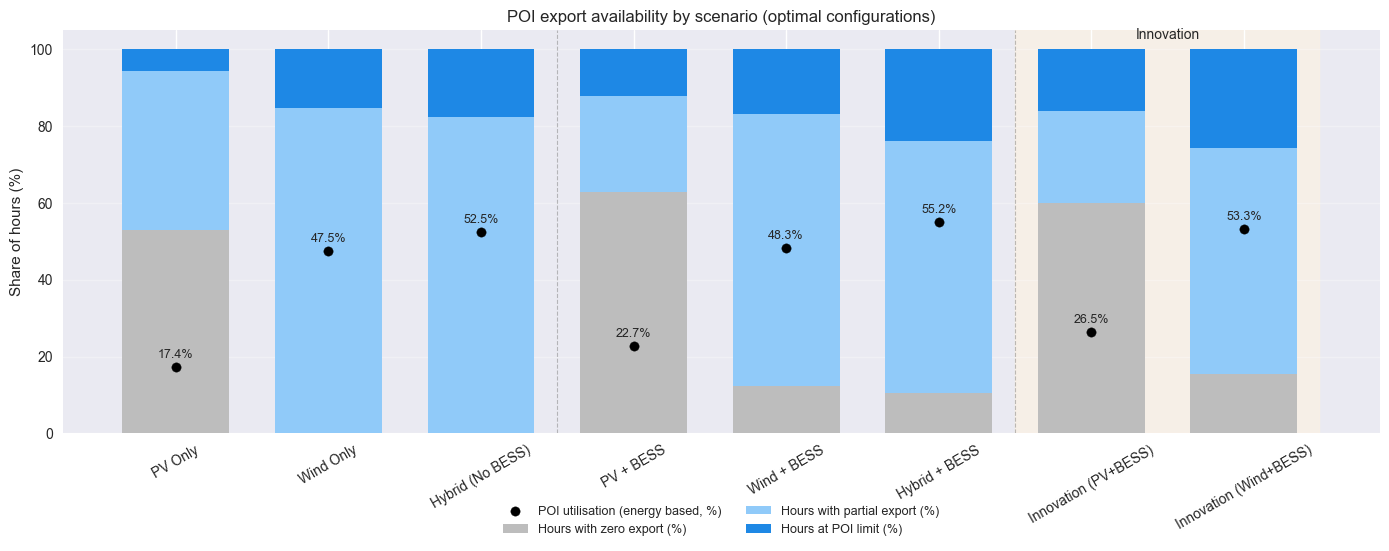

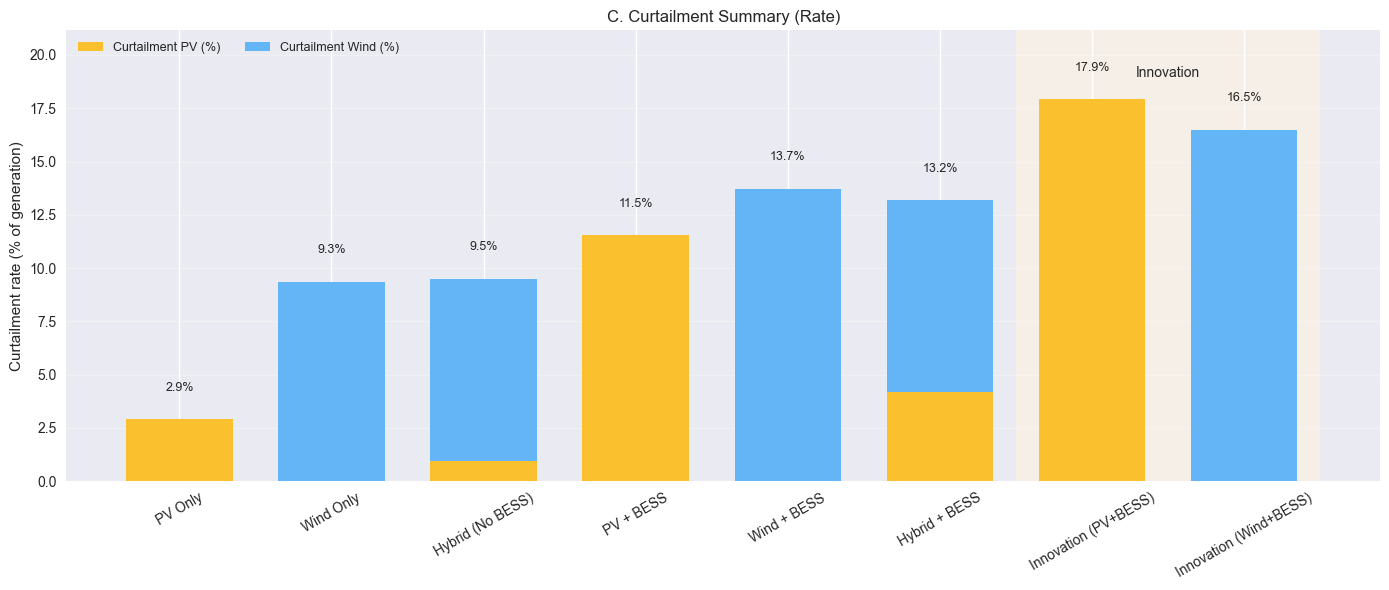

In [100]:
# Stacked export availability profile + POI utilisation markers
if not dispatch_results:
    raise ValueError("dispatch_results is empty; run the duration curve cell first.")

scenario_order = [
    'PV Only',
    'Wind Only',
    'Hybrid (No BESS)',
    'PV + BESS',
    'Wind + BESS',
    'Hybrid + BESS',
    'Innovation (PV+BESS)',
    'Innovation (Wind+BESS)',
]
scenario_names = [name for name in scenario_order if name in summary.index and name in dispatch_results]

tol_mw = 1e-3 * POI_CAPACITY_MW  # tolerance for float noise

rows = []
for name in scenario_names:
    export = np.asarray(dispatch_results[name]["export_mw"], dtype=float)
    if export.size == 0:
        continue
    hours_at_poi = np.mean(export >= (POI_CAPACITY_MW - tol_mw)) * 100.0
    hours_zero = np.mean(export <= tol_mw) * 100.0
    hours_partial = max(0.0, 100.0 - hours_at_poi - hours_zero)
    rows.append({
        'Scenario': name,
        'Hours at POI limit (%)': hours_at_poi,
        'Hours with zero export (%)': hours_zero,
        'Hours with partial export (%)': hours_partial,
        'POI Utilisation (%)': summary.loc[name, 'poi_utilisation_pct'],
    })

metrics_df = pd.DataFrame(rows)
if metrics_df.empty:
    raise ValueError('No scenarios available for export availability plot.')

x = np.arange(len(metrics_df))
width = 0.7

colors = {
    'Hours with zero export (%)': '#BDBDBD',
    'Hours with partial export (%)': '#90CAF9',
    'Hours at POI limit (%)': '#1E88E5',
}

fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(metrics_df))
for key in ['Hours with zero export (%)', 'Hours with partial export (%)', 'Hours at POI limit (%)']:
    values = metrics_df[key].to_numpy()
    ax.bar(x, values, width, bottom=bottom, color=colors[key], label=key)
    # No labels on bar segments to avoid overlap with POI utilisation dots
    bottom += values

# Overlay POI utilisation as a dot per scenario
util = metrics_df['POI Utilisation (%)'].to_numpy()
ax.scatter(x, util, color='black', zorder=5, s=45, label='POI utilisation (energy based, %)')
for i, v in enumerate(util):
    ax.text(x[i], v + 1.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

# Add vertical separators between groups
# Merchant without storage (first 3)
if len(metrics_df) >= 3:
    ax.axvline(x=2.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, zorder=1)
# Merchant with storage (next 3)
if len(metrics_df) >= 6:
    ax.axvline(x=5.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, zorder=1)

# Visually separate innovation scenarios with a light background box
innovation_mask = metrics_df['Scenario'].str.contains('Innovation')
if innovation_mask.any():
    idx = np.where(innovation_mask.to_numpy())[0]
    start = idx.min() - 0.5
    end = idx.max() + 0.5
    ax.axvspan(start, end, color='#FFF3E0', alpha=0.6, zorder=0)
    ax.text((start + end) / 2, 102, 'Innovation', ha='center', va='bottom', fontsize=10)

ax.set_title('POI export availability by scenario (optimal configurations)')
ax.set_ylabel('Share of hours (%)')
ax.set_xlabel('')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df['Scenario'], rotation=30)
ax.set_ylim(0, 105)
ax.grid(True, axis='y', alpha=0.3)
ax.legend(ncol=2, fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.15))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# C. Curtailment summary (single panel)
rows = []
for name in scenario_names:
    result = dispatch_results[name]
    if "curtailment_mw" not in result.columns or "export_mw" not in result.columns:
        continue
    total_curt = np.asarray(result["curtailment_mw"], dtype=float)
    total_export = np.asarray(result["export_mw"], dtype=float)
    total_curt_mwh = float(np.nansum(total_curt))
    total_export_mwh = float(np.nansum(total_export))
    total_gen_mwh = total_curt_mwh + total_export_mwh
    if "curtailment_pv_mw" in result.columns and "curtailment_wind_mw" in result.columns:
        pv_curt = float(np.nansum(result["curtailment_pv_mw"]))
        wind_curt = float(np.nansum(result["curtailment_wind_mw"]))
    else:
        s_wind = float(summary.loc[name, "s_wind"])
        if s_wind <= 0:
            pv_curt = total_curt_mwh
            wind_curt = 0.0
        elif s_wind >= 1:
            pv_curt = 0.0
            wind_curt = total_curt_mwh
        else:
            pv_curt = total_curt_mwh * (1 - s_wind)
            wind_curt = total_curt_mwh * s_wind
    if total_gen_mwh <= 0:
        pv_rate = 0.0
        wind_rate = 0.0
        total_rate = 0.0
    else:
        pv_rate = pv_curt / total_gen_mwh * 100.0
        wind_rate = wind_curt / total_gen_mwh * 100.0
        total_rate = (pv_curt + wind_curt) / total_gen_mwh * 100.0
    rows.append({
        "Scenario": name,
        "Curtailment PV (%)": pv_rate,
        "Curtailment Wind (%)": wind_rate,
        "Curtailment total (%)": total_rate,
    })

curtail_df = pd.DataFrame(rows)
if curtail_df.empty:
    raise ValueError("No curtailment data available for summary plot.")

x = np.arange(len(curtail_df))
width = 0.7
curtail_colors = {
    "Curtailment PV (%)": "#FBC02D",
    "Curtailment Wind (%)": "#64B5F6",
}

fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(curtail_df))
for key in ["Curtailment PV (%)", "Curtailment Wind (%)"]:
    values = curtail_df[key].to_numpy()
    ax.bar(x, values, width, bottom=bottom, color=curtail_colors[key], label=key)
    bottom += values

total_vals = curtail_df["Curtailment total (%)"].to_numpy()
for i, v in enumerate(total_vals):
    ax.text(x[i], v + 1.2, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

y_max = max(1.0, float(np.max(total_vals)))
ax.set_ylim(0, y_max * 1.18)

# Reuse innovation shading from the availability plot
innovation_mask_curt = curtail_df["Scenario"].str.contains("Innovation")
if innovation_mask_curt.any():
    idx = np.where(innovation_mask_curt.to_numpy())[0]
    start = idx.min() - 0.5
    end = idx.max() + 0.5
    ax.axvspan(start, end, color="#FFF3E0", alpha=0.6, zorder=0)
    ax.text((start + end) / 2, y_max * 1.05, "Innovation", ha="center", va="bottom", fontsize=10)

ax.set_title("C. Curtailment Summary (Rate)")
ax.set_ylabel("Curtailment rate (% of generation)")
ax.set_xlabel("")
ax.set_xticks(x)
ax.set_xticklabels(curtail_df["Scenario"], rotation=30)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


## 5. Price Capture & Shifted Energy Value

- Capture price (export-weighted) per scenario
- Average discharge vs charge opportunity price (DA), plus delta


/var/folders/2p/bk483h253013txglty1ym51m0000gn/T/ipykernel_8559/3932624466.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


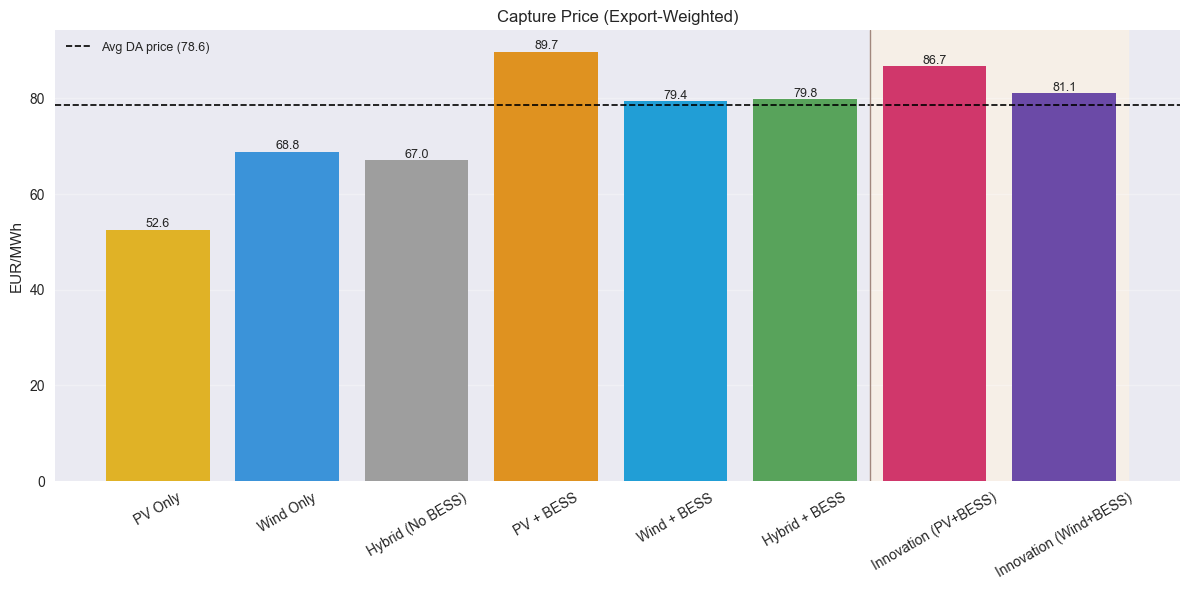

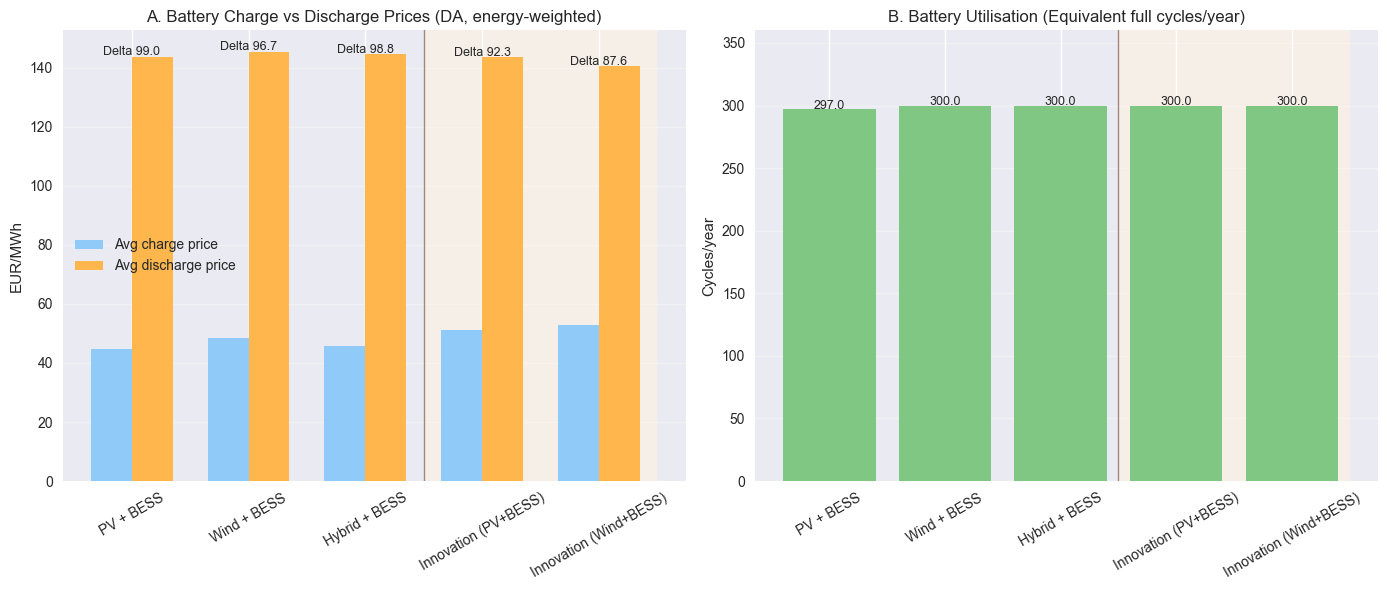

In [101]:
# Price capture and shifted energy metrics
if not dispatch_results:
    raise ValueError("dispatch_results is empty; run the duration curve cell first.")

if "scenario_colors" not in globals():
    base_colors = [
        "#FFC107",
        "#2196F3",
        "#9E9E9E",
        "#FF9800",
        "#03A9F4",
        "#4CAF50",
        "#E91E63",
        "#673AB7",
    ]
    scenario_colors = {
        name: base_colors[i % len(base_colors)]
        for i, name in enumerate(dispatch_results.keys())
    }

scenario_order = [
    "PV Only",
    "Wind Only",
    "Hybrid (No BESS)",
    "PV + BESS",
    "Wind + BESS",
    "Hybrid + BESS",
    "Innovation (PV+BESS)",
    "Innovation (Wind+BESS)",
]


def _weighted_avg(price, weight):
    total = np.nansum(weight)
    if total <= 0:
        return np.nan
    return np.nansum(price * weight) / total


def _attach_price(result_df, hourly_df):
    if "price_eur_mwh" in result_df.columns:
        return result_df, result_df["price_eur_mwh"].to_numpy()
    if "timestamp" in result_df.columns:
        merged = result_df.merge(
            hourly_df[["timestamp", "price_eur_per_mwh"]],
            on="timestamp",
            how="left",
        )
        return merged, merged["price_eur_per_mwh"].to_numpy()
    # Fallback: assume same order
    price = hourly_df["price_eur_per_mwh"].to_numpy()[: len(result_df)]
    merged = result_df.copy()
    merged["price_eur_per_mwh"] = price
    return merged, price


metrics = []
for name, result in dispatch_results.items():
    enriched, price = _attach_price(result, hourly_df)
    export_mw = enriched["export_mw"].to_numpy()
    capture_price = _weighted_avg(price, export_mw)

    charge_price = np.nan
    discharge_price = np.nan
    charge_mwh = np.nan
    discharge_mwh = np.nan
    if "charge_mw" in enriched.columns and "discharge_mw" in enriched.columns:
        charge_mw = np.clip(enriched["charge_mw"].to_numpy(), 0.0, None)
        discharge_mw = np.clip(enriched["discharge_mw"].to_numpy(), 0.0, None)
        charge_price = _weighted_avg(price, charge_mw)
        discharge_price = _weighted_avg(price, discharge_mw)
        charge_mwh = float(np.nansum(charge_mw))
        discharge_mwh = float(np.nansum(discharge_mw))

    metrics.append({
        "scenario": name,
        "capture_price_eur_mwh": capture_price,
        "charge_price_eur_mwh": charge_price,
        "discharge_price_eur_mwh": discharge_price,
        "delta_price_eur_mwh": discharge_price - charge_price
        if np.isfinite(charge_price) and np.isfinite(discharge_price)
        else np.nan,
        "charge_mwh": charge_mwh,
        "discharge_mwh": discharge_mwh,
        "bess_energy_mwh": summary.loc[name, "bess_energy_mwh"],
        "has_bess": summary.loc[name, "bess_power_mw"] > 0,
    })

metrics_df = pd.DataFrame(metrics).set_index("scenario")
scenario_names = [name for name in scenario_order if name in metrics_df.index]
metrics_df = metrics_df.loc[scenario_names]

metrics_df["cycles_per_year"] = np.where(
    (metrics_df["bess_energy_mwh"] > 0) & np.isfinite(metrics_df["discharge_mwh"]),
    metrics_df["discharge_mwh"] / metrics_df["bess_energy_mwh"],
    np.nan,
)

# Capture price chart
fig, ax = plt.subplots(figsize=(12, 6))
colors = [scenario_colors.get(name, "#666666") for name in metrics_df.index]

sns.barplot(
    x=metrics_df.index,
    y="capture_price_eur_mwh",
    data=metrics_df.reset_index(),
    palette=colors,
    ax=ax,
)

annual_avg_price = float(hourly_df["price_eur_per_mwh"].mean())
ax.axhline(
    annual_avg_price,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Avg DA price ({annual_avg_price:.1f})",
)

innovation_mask = metrics_df.index.to_series().str.contains("Innovation")
if innovation_mask.any():
    idx = np.where(innovation_mask.to_numpy())[0]
    start = idx.min() - 0.5
    end = idx.max() + 0.5
    ax.axvspan(start, end, color="#FFF3E0", alpha=0.6, zorder=0)
    ax.axvline(start, color="#8D6E63", linewidth=1.0, alpha=0.8)

ax.set_title("Capture Price (Export-Weighted)")
ax.set_ylabel("EUR/MWh")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=30)
for i, value in enumerate(metrics_df["capture_price_eur_mwh"].values):
    if np.isfinite(value):
        ax.text(i, value + 0.5, f"{value:.1f}", ha="center", fontsize=9)

ax.grid(True, axis="y", alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Charge vs discharge prices + utilisation for BESS scenarios
bess_metrics = metrics_df[metrics_df["has_bess"]]
if bess_metrics.empty:
    print("No BESS scenarios found for charge/discharge price comparison.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    x = np.arange(len(bess_metrics))
    width = 0.35

    ax = axes[0]
    ax.bar(
        x - width / 2,
        bess_metrics["charge_price_eur_mwh"],
        width,
        label="Avg charge price",
        color="#90CAF9",
    )
    ax.bar(
        x + width / 2,
        bess_metrics["discharge_price_eur_mwh"],
        width,
        label="Avg discharge price",
        color="#FFB74D",
    )

    innovation_mask_bess = bess_metrics.index.to_series().str.contains("Innovation")
    if innovation_mask_bess.any():
        idx = np.where(innovation_mask_bess.to_numpy())[0]
        start = idx.min() - 0.5
        end = idx.max() + 0.5
        ax.axvspan(start, end, color="#FFF3E0", alpha=0.6, zorder=0)
        ax.axvline(start, color="#8D6E63", linewidth=1.0, alpha=0.8)

    ax.set_title("A. Battery Charge vs Discharge Prices (DA, energy-weighted)")
    ax.set_ylabel("EUR/MWh")
    ax.set_xlabel("")
    ax.set_xticks(x)
    ax.set_xticklabels(bess_metrics.index, rotation=30)
    ax.grid(True, axis="y", alpha=0.3)

    for i, (charge, discharge, delta) in enumerate(
        zip(
            bess_metrics["charge_price_eur_mwh"],
            bess_metrics["discharge_price_eur_mwh"],
            bess_metrics["delta_price_eur_mwh"],
        )
    ):
        if np.isfinite(delta):
            y = max(charge, discharge)
            ax.text(i, y + 0.5, f"Delta {delta:.1f}", ha="center", fontsize=9)

    ax.legend()

    ax = axes[1]
    cycles = bess_metrics["cycles_per_year"].to_numpy()
    ax.bar(x, cycles, color="#81C784")
    for i, v in enumerate(cycles):
        if np.isfinite(v):
            ax.text(i, v + 0.1, f"{v:.1f}", ha="center", fontsize=9)

    y_max = float(np.nanmax(cycles)) if np.isfinite(np.nanmax(cycles)) else 1.0
    ax.set_ylim(0, max(1.0, y_max) * 1.2)

    if innovation_mask_bess.any():
        idx = np.where(innovation_mask_bess.to_numpy())[0]
        start = idx.min() - 0.5
        end = idx.max() + 0.5
        ax.axvspan(start, end, color="#FFF3E0", alpha=0.6, zorder=0)
        ax.axvline(start, color="#8D6E63", linewidth=1.0, alpha=0.8)

    ax.set_title("B. Battery Utilisation (Equivalent full cycles/year)")
    ax.set_ylabel("Cycles/year")
    ax.set_xlabel("")
    ax.set_xticks(x)
    ax.set_xticklabels(bess_metrics.index, rotation=30)
    ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


## 6. Battery Dispatch & SOC Examples

Two representative weeks for battery dispatch and SOC:
- Summer week with high PV curtailment
- Winter week with high wind variability


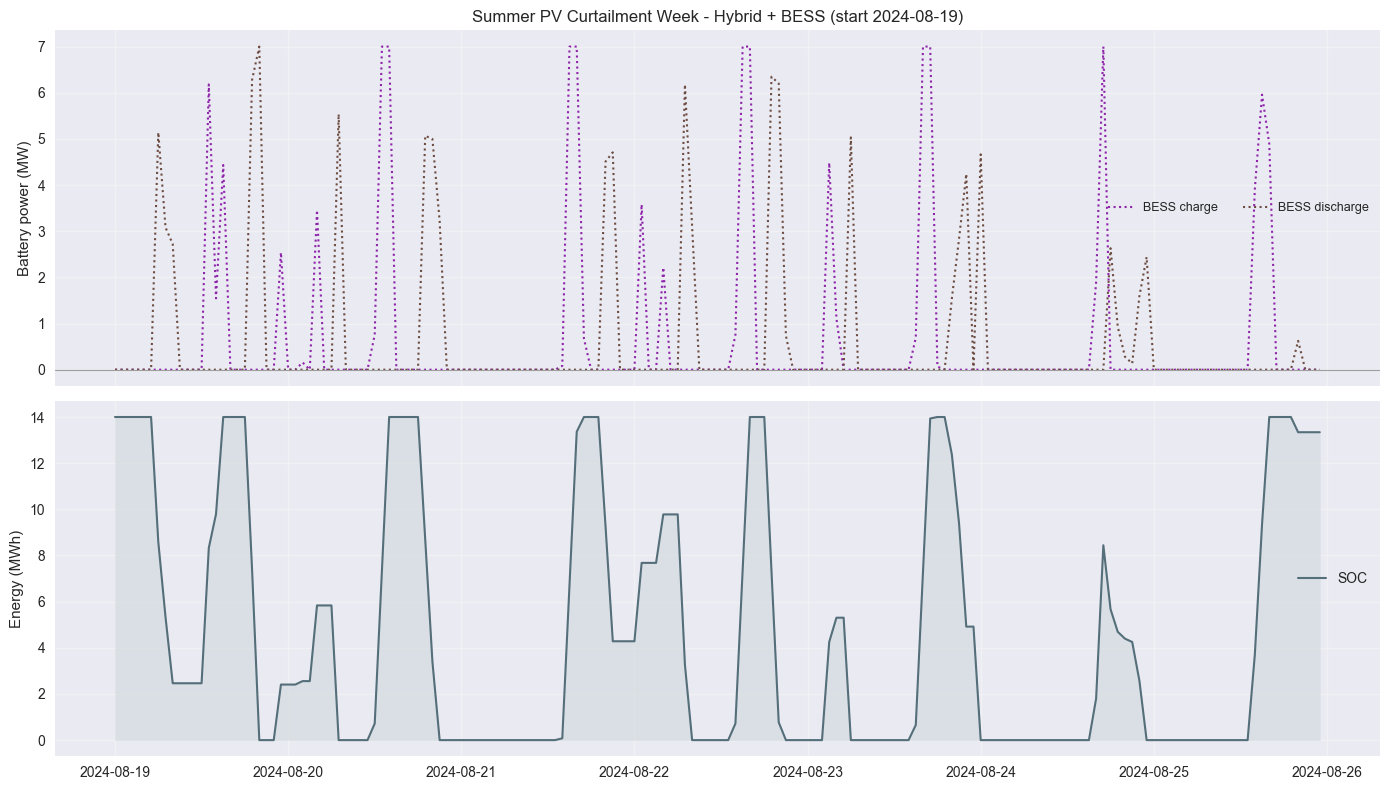

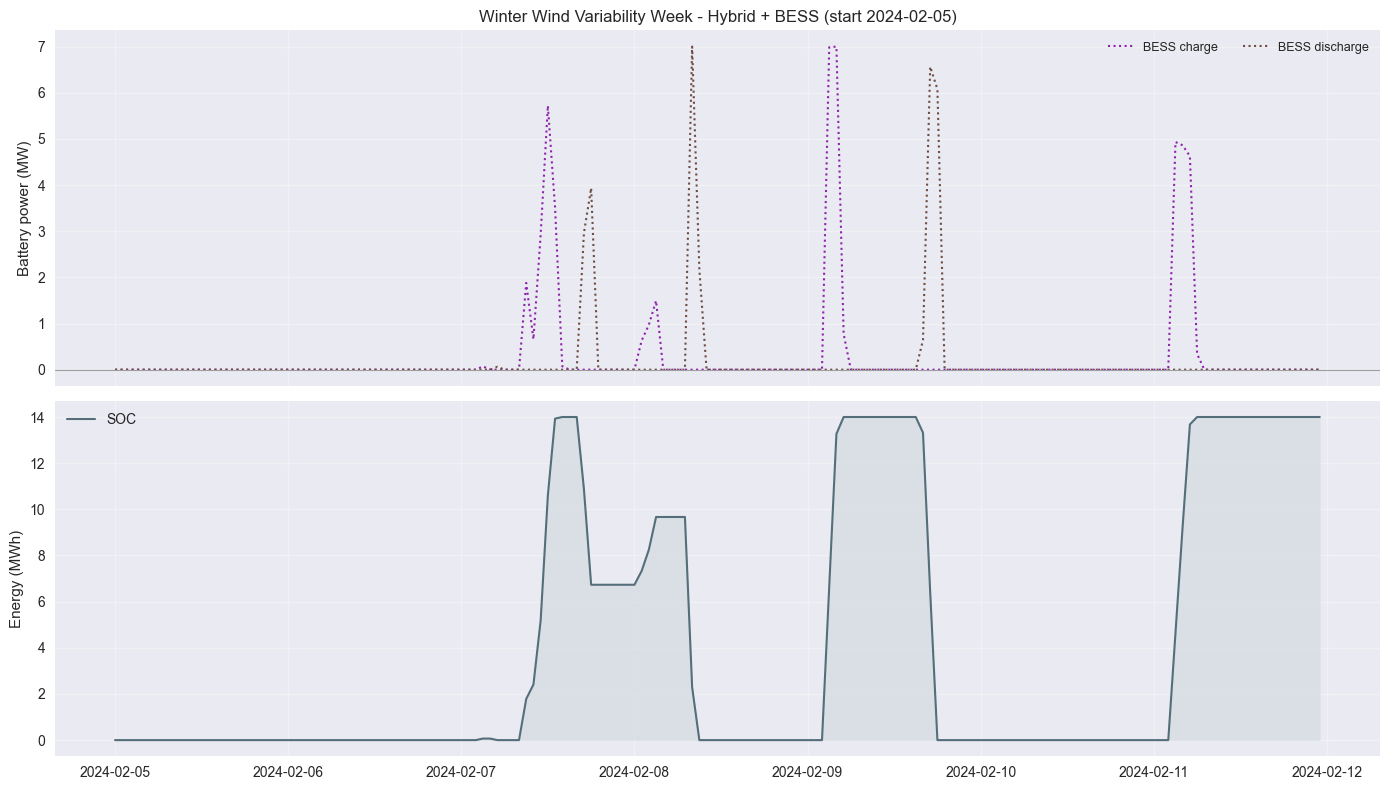

In [102]:
# Battery dispatch and SOC examples (two representative weeks)
if not dispatch_results:
    raise ValueError("dispatch_results is empty; run the duration curve cell first.")

scenario_name = None
if "Hybrid + BESS" in dispatch_results:
    scenario_name = "Hybrid + BESS"
else:
    for name, result in dispatch_results.items():
        if "charge_mw" in result.columns and "discharge_mw" in result.columns:
            scenario_name = name
            break

if scenario_name is None:
    raise ValueError("No BESS dispatch results found for SOC example plots.")

row = summary.loc[scenario_name]
pv_capacity_mw = row["alpha_tot"] * POI_CAPACITY_MW * (1 - row["s_wind"])
wind_capacity_mw = row["alpha_tot"] * POI_CAPACITY_MW * row["s_wind"]

example_df = dispatch_results[scenario_name].copy()
if "timestamp" not in example_df.columns:
    example_df["timestamp"] = hourly_df["timestamp"].values[: len(example_df)]
example_df["timestamp"] = pd.to_datetime(example_df["timestamp"])

if "pv_generation_mw" not in example_df.columns:
    example_df["pv_generation_mw"] = hourly_df["pv_per_kw"].values[: len(example_df)] * pv_capacity_mw
if "wind_generation_mw" not in example_df.columns:
    example_df["wind_generation_mw"] = hourly_df["wind_per_kw"].values[: len(example_df)] * wind_capacity_mw

required_cols = ["export_mw", "curtailment_mw", "charge_mw", "discharge_mw", "soc_mwh"]
missing = [col for col in required_cols if col not in example_df.columns]
if missing:
    raise ValueError(f"Missing columns for dispatch plot: {missing}")

example_df = example_df.set_index("timestamp").sort_index()

# Pick representative weeks
summer_df = example_df[example_df.index.month.isin([6, 7, 8])]
if summer_df.empty:
    raise ValueError("No summer data found for the dispatch example week.")

summer_curtail = summer_df["curtailment_mw"].resample("W-MON", label="left", closed="left").sum()
summer_start = summer_curtail.idxmax()

winter_df = example_df[example_df.index.month.isin([12, 1, 2])]
if winter_df.empty:
    raise ValueError("No winter data found for the dispatch example week.")

winter_wind_var = winter_df["wind_generation_mw"].resample("W-MON", label="left", closed="left").std()
winter_start = winter_wind_var.idxmax()


def _slice_week(df, start):
    end = start + pd.Timedelta(days=7)
    return df.loc[start:end - pd.Timedelta(hours=1)]


def _plot_week(df, start, title):
    week = _slice_week(df, start)
    if week.empty:
        print(f"Skipped {title}: no data for that week")
        return

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    ax = axes[0]
    ax.plot(week.index, week["charge_mw"], label="BESS charge", color="#8E24AA", linestyle=":", linewidth=1.5)
    ax.plot(week.index, week["discharge_mw"], label="BESS discharge", color="#6D4C41", linestyle=":", linewidth=1.5)
    ax.axhline(0, color="#9E9E9E", linewidth=0.8)

    ax.set_ylabel("Battery power (MW)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=9)

    ax_soc = axes[1]
    ax_soc.plot(week.index, week["soc_mwh"], label="SOC", color="#546E7A", linewidth=1.5)
    ax_soc.fill_between(week.index, 0, week["soc_mwh"], color="#CFD8DC", alpha=0.6)
    ax_soc.set_ylabel("Energy (MWh)")
    ax_soc.grid(True, alpha=0.3)
    ax_soc.legend()

    plt.tight_layout()
    plt.show()


_plot_week(
    example_df,
    summer_start,
    f"Summer PV Curtailment Week - {scenario_name} (start {summer_start.date()})",
)
_plot_week(
    example_df,
    winter_start,
    f"Winter Wind Variability Week - {scenario_name} (start {winter_start.date()})",
)



## 7. Value Decomposition Waterfalls

Incremental value breakdown for adding BESS to each tech.


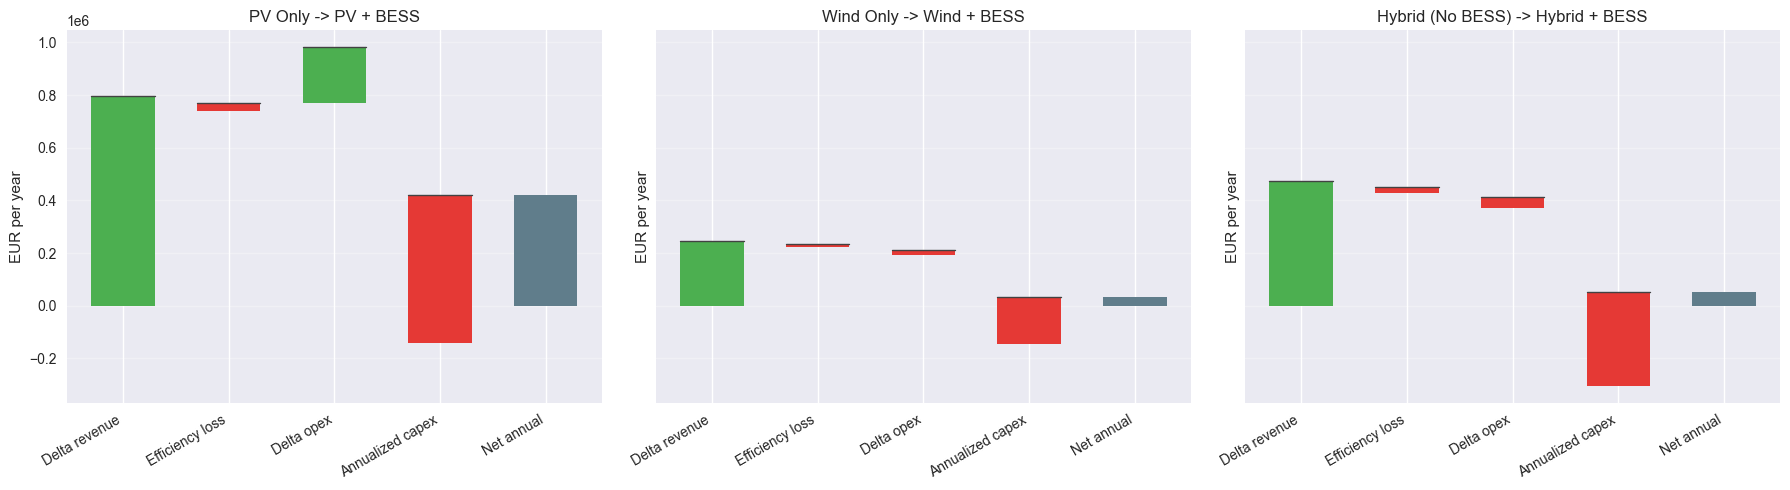

In [103]:
# Value decomposition waterfall (incremental to BESS)
if not dispatch_results:
    raise ValueError("dispatch_results is empty; run the duration curve cell first.")

from config import PROJECT_LIFETIME_YEARS, WACC_BESS_REAL

pairs = [
    ("PV Only", "PV + BESS"),
    ("Wind Only", "Wind + BESS"),
    ("Hybrid (No BESS)", "Hybrid + BESS"),
]


def _annualized_capex(delta_capex_eur, rate, years):
    if years <= 0:
        return np.nan
    if rate <= 0:
        return delta_capex_eur / years
    factor = (rate * (1 + rate) ** years) / ((1 + rate) ** years - 1)
    return delta_capex_eur * factor


def _loss_value_eur(dispatch_df):
    if "charge_mw" not in dispatch_df.columns or "discharge_mw" not in dispatch_df.columns:
        return 0.0
    if "price_eur_mwh" in dispatch_df.columns:
        price = dispatch_df["price_eur_mwh"].to_numpy()
    else:
        price = hourly_df["price_eur_per_mwh"].to_numpy()[: len(dispatch_df)]
    charge = np.clip(dispatch_df["charge_mw"].to_numpy(), 0.0, None)
    discharge = np.clip(dispatch_df["discharge_mw"].to_numpy(), 0.0, None)
    loss_mwh = max(charge.sum() - discharge.sum(), 0.0)
    charge_price = _weighted_avg(price, charge) if charge.sum() > 0 else np.nan
    if not np.isfinite(charge_price):
        return 0.0
    return loss_mwh * charge_price


waterfall_data = []
for base_name, bess_name in pairs:
    if base_name not in comparison_df.index or bess_name not in comparison_df.index:
        continue

    base = comparison_df.loc[base_name]
    bess = comparison_df.loc[bess_name]

    delta_revenue = bess.get("annual_revenue_eur", np.nan) - base.get("annual_revenue_eur", np.nan)
    delta_opex = bess.get("annual_opex_total_eur", np.nan) - base.get("annual_opex_total_eur", np.nan)
    delta_capex = bess.get("capex_total_eur", np.nan) - base.get("capex_total_eur", np.nan)

    loss_value = 0.0
    if bess_name in dispatch_results:
        loss_value = _loss_value_eur(dispatch_results[bess_name])

    rate = bess.get("wacc", WACC_BESS_REAL)
    annualized_capex = _annualized_capex(delta_capex, rate, PROJECT_LIFETIME_YEARS)

    waterfall_data.append({
        "pair": f"{base_name} -> {bess_name}",
        "delta_revenue": delta_revenue,
        "loss_value": loss_value,
        "delta_opex": delta_opex,
        "annualized_capex": annualized_capex,
    })

if not waterfall_data:
    print("No valid scenario pairs found for value decomposition.")
else:
    fig, axes = plt.subplots(1, len(waterfall_data), figsize=(6 * len(waterfall_data), 5), sharey=True)
    if len(waterfall_data) == 1:
        axes = [axes]

    for ax, item in zip(axes, waterfall_data):
        values = [
            item["delta_revenue"],
            -item["loss_value"],
            -item["delta_opex"],
            -item["annualized_capex"],
        ]
        labels = [
            "Delta revenue",
            "Efficiency loss",
            "Delta opex",
            "Annualized capex",
        ]

        cumulative = 0.0
        for i, (label, val) in enumerate(zip(labels, values)):
            color = "#4CAF50" if val >= 0 else "#E53935"
            bottom = cumulative if val >= 0 else cumulative + val
            ax.bar(i, val, bottom=bottom, color=color, width=0.6)
            cumulative += val
            ax.plot([i - 0.3, i + 0.3], [cumulative, cumulative], color="#424242", linewidth=1)

        ax.bar(len(labels), cumulative, color="#607D8B", width=0.6)
        ax.set_xticks(range(len(labels) + 1))
        ax.set_xticklabels(labels + ["Net annual"], rotation=30, ha="right")
        ax.set_title(item["pair"])
        ax.grid(True, axis="y", alpha=0.3)
        ax.set_ylabel("EUR per year")

    plt.tight_layout()
    plt.show()


## 8. Congestion & Correlation

Congestion (POI limit hours) and price relationships.


/var/folders/2p/bk483h253013txglty1ym51m0000gn/T/ipykernel_8559/1716361751.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = pd.Series(curtailment).groupby(bins).sum()
/var/folders/2p/bk483h253013txglty1ym51m0000gn/T/ipykernel_8559/1716361751.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = pd.Series(curtailment).groupby(bins).sum()
/var/folders/2p/bk483h253013txglty1ym51m0000gn/T/ipykernel_8559/1716361751.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obse

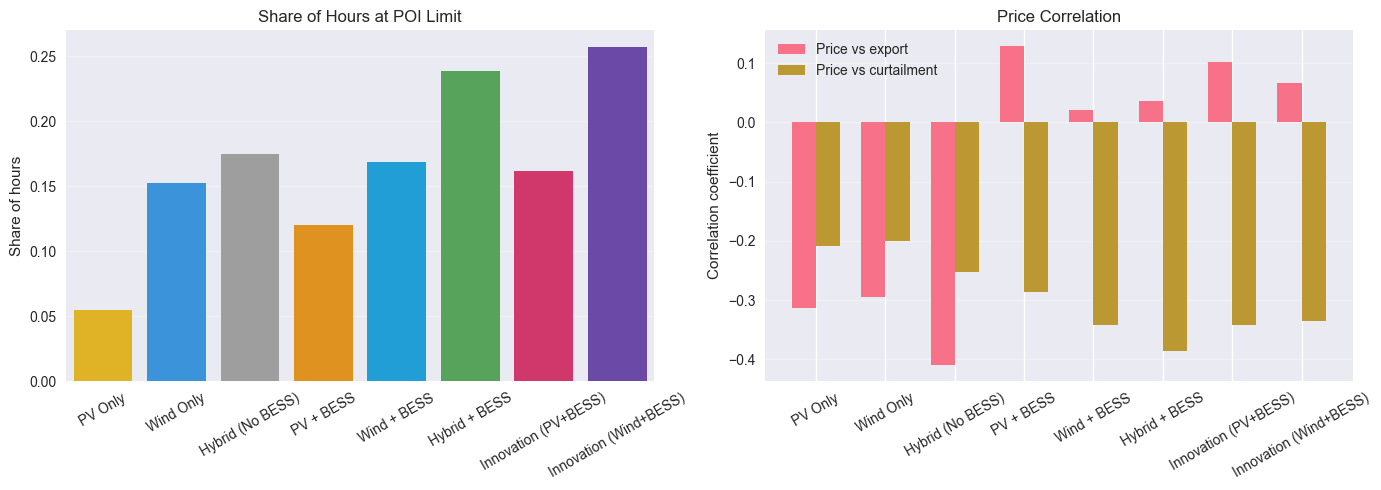

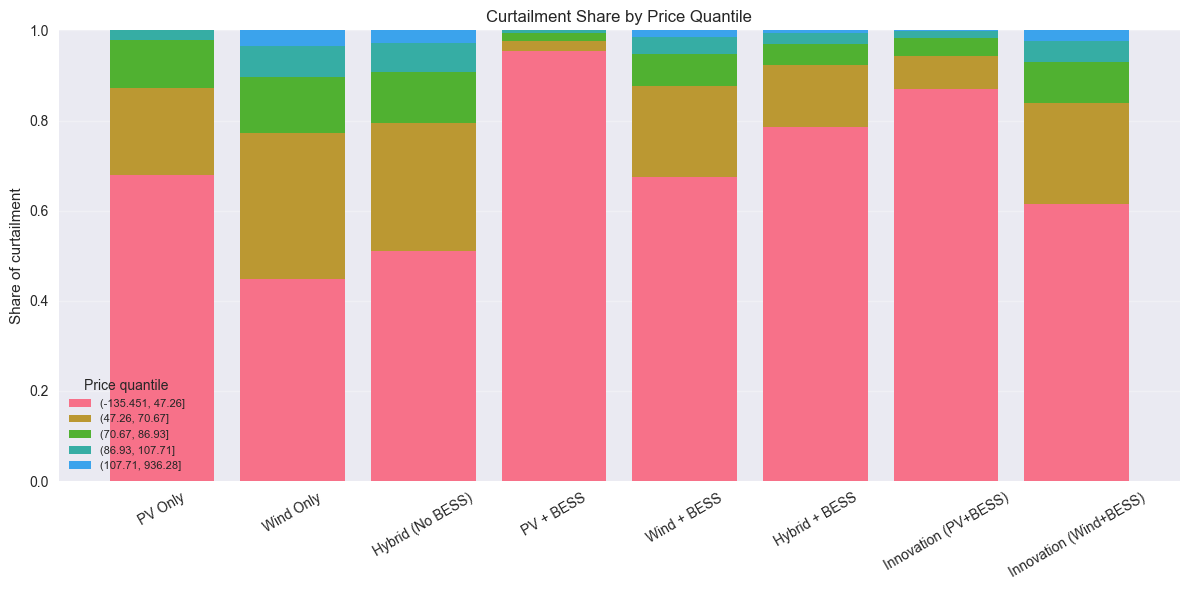

In [104]:
# Congestion and correlation plots
if not dispatch_results:
    raise ValueError("dispatch_results is empty; run the duration curve cell first.")

if "scenario_colors" not in globals():
    base_colors = [
        "#FFC107",
        "#2196F3",
        "#9E9E9E",
        "#FF9800",
        "#03A9F4",
        "#4CAF50",
        "#E91E63",
        "#673AB7",
    ]
    scenario_colors = {
        name: base_colors[i % len(base_colors)]
        for i, name in enumerate(dispatch_results.keys())
    }


def _attach_price_local(result_df, hourly_df):
    if "price_eur_mwh" in result_df.columns:
        return result_df, result_df["price_eur_mwh"].to_numpy()
    if "timestamp" in result_df.columns:
        merged = result_df.merge(
            hourly_df[["timestamp", "price_eur_per_mwh"]],
            on="timestamp",
            how="left",
        )
        return merged, merged["price_eur_per_mwh"].to_numpy()
    price = hourly_df["price_eur_per_mwh"].to_numpy()[: len(result_df)]
    merged = result_df.copy()
    merged["price_eur_per_mwh"] = price
    return merged, price


stats = []
price_all = hourly_df["price_eur_per_mwh"].to_numpy()
quantile_edges = np.quantile(price_all, [0, 0.2, 0.4, 0.6, 0.8, 1.0])
quantile_edges = np.unique(quantile_edges)

for name, result in dispatch_results.items():
    enriched, price = _attach_price_local(result, hourly_df)
    export = enriched["export_mw"].to_numpy()
    curtailment = enriched["curtailment_mw"].to_numpy()

    congestion_share = np.mean(export >= POI_CAPACITY_MW * 0.999)

    corr_export = np.nan
    corr_curtail = np.nan
    if np.std(price) > 0 and np.std(export) > 0:
        corr_export = np.corrcoef(price, export)[0, 1]
    if np.std(price) > 0 and np.std(curtailment) > 0:
        corr_curtail = np.corrcoef(price, curtailment)[0, 1]

    quantile_labels = []
    curtailment_shares = []
    if len(quantile_edges) > 1:
        bins = pd.cut(price, bins=quantile_edges, include_lowest=True)
        total_curtail = curtailment.sum()
        grouped = pd.Series(curtailment).groupby(bins).sum()
        for bin_label, value in grouped.items():
            quantile_labels.append(str(bin_label))
            share = value / total_curtail if total_curtail > 0 else 0.0
            curtailment_shares.append(share)

    stats.append({
        "scenario": name,
        "congestion_share": congestion_share,
        "corr_export": corr_export,
        "corr_curtail": corr_curtail,
        "curtailment_shares": curtailment_shares,
        "quantile_labels": quantile_labels,
    })

stats_df = pd.DataFrame(stats).set_index("scenario")

# Congestion share plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    x=stats_df.index,
    y="congestion_share",
    data=stats_df.reset_index(),
    palette=[scenario_colors.get(name, "#666666") for name in stats_df.index],
    ax=axes[0],
)
axes[0].set_title("Share of Hours at POI Limit")
axes[0].set_ylabel("Share of hours")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(True, axis="y", alpha=0.3)

# Correlation bars
x = np.arange(len(stats_df))
width = 0.35
axes[1].bar(x - width / 2, stats_df["corr_export"], width, label="Price vs export")
axes[1].bar(x + width / 2, stats_df["corr_curtail"], width, label="Price vs curtailment")
axes[1].set_xticks(x)
axes[1].set_xticklabels(stats_df.index, rotation=30)
axes[1].set_title("Price Correlation")
axes[1].set_ylabel("Correlation coefficient")
axes[1].grid(True, axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Curtailment by price quantile (stacked)
if len(stats_df.iloc[0]["curtailment_shares"]) > 0:
    quantile_labels = stats_df.iloc[0]["quantile_labels"]
    fig, ax = plt.subplots(figsize=(12, 6))

    bottom = np.zeros(len(stats_df))
    for i, q_label in enumerate(quantile_labels):
        values = [shares[i] if i < len(shares) else 0.0 for shares in stats_df["curtailment_shares"]]
        ax.bar(stats_df.index, values, bottom=bottom, label=q_label)
        bottom += np.array(values)

    ax.set_title("Curtailment Share by Price Quantile")
    ax.set_ylabel("Share of curtailment")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Price quantile", fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Skipped curtailment quantile plot: insufficient price binning.")
